In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

Limpieza y analisis de diciembre + unirlo a Noviembre: 

- https://www.eurowings.com/es/informar/sobre-nosotros/tecnologia-y-flota.html
- https://www.flightaware.com/live/flight/EWG9443/history/20251121/1845Z/LEBL/EDDL
- https://www.aeropuertobarcelona-elprat.com/cast/salidas-aeropuerto-barcelona.html?t=9-12&a=2

In [2]:
df = pd.read_csv("vuelos_Enero_rellenados.csv")
df

,Unnamed: 0,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
0,0,01/12/2025,Ryanair,FR3180,Rome (FCO),06:00,"En hora, Ha salido",189.0,Boeing 737-800,S25
1,1,01/12/2025,Ryanair,FR846,Milan (BGY),06:10,"En hora, Ha salido",189.0,Boeing 737-800,S20
2,2,01/12/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,"En hora, Ha salido",156.0,Airbus A319,R11
3,3,01/12/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,"En hora, Ha salido",189.0,Boeing 737-800,W45
4,4,01/12/2025,Ryanair,FR8384,Budapest (BUD),06:25,"En hora, Ha salido",197.0,Boeing 737 MAX 8,U33
...,...,...,...,...,...,...,...,...,...,...
919,919,07/12/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W43
920,920,07/12/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"En hora, Programado",230.0,Airbus A321,W44
921,921,07/12/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",189.0,Boeing 737-800,U31
922,922,07/12/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",239.0,Airbus A321neo,S22


In [3]:
df.isna().sum()[df.isna().sum() > 0] 

Series([], dtype: int64)

In [4]:
df = df.drop(columns= ['Unnamed: 0'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha_scrapeo    924 non-null    object 
 1   Name_company     924 non-null    object 
 2   Num_flight       924 non-null    object 
 3   Name_Destiny     924 non-null    object 
 4   Time_flight      924 non-null    object 
 5   flight_state     924 non-null    object 
 6   flight_capacity  924 non-null    float64
 7   Aircraft         924 non-null    object 
 8   Gate             924 non-null    object 
dtypes: float64(1), object(8)
memory usage: 65.1+ KB


In [6]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
0,01/12/2025,Ryanair,FR3180,Rome (FCO),06:00,"En hora, Ha salido",189.0,Boeing 737-800,S25
1,01/12/2025,Ryanair,FR846,Milan (BGY),06:10,"En hora, Ha salido",189.0,Boeing 737-800,S20
2,01/12/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,"En hora, Ha salido",156.0,Airbus A319,R11
3,01/12/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,"En hora, Ha salido",189.0,Boeing 737-800,W45
4,01/12/2025,Ryanair,FR8384,Budapest (BUD),06:25,"En hora, Ha salido",197.0,Boeing 737 MAX 8,U33
...,...,...,...,...,...,...,...,...,...
919,07/12/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W43
920,07/12/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"En hora, Programado",230.0,Airbus A321,W44
921,07/12/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",189.0,Boeing 737-800,U31
922,07/12/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",239.0,Airbus A321neo,S22


In [7]:
df[df.Gate == 'Y']

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
82,01/12/2025,Bluebird Airways,BZ251,Tel Aviv (TLV),14:45,"Retrasado, Programado 14:56",189.0,Boeing 737-800,Y
213,02/12/2025,Bluebird Airways,BZ251,Tel Aviv (TLV),14:45,"En hora, Programado",189.0,Boeing 737-800,Y
263,03/12/2025,Air Arabia Maroc,3O642,Tanger (TNG),10:05,"En hora, Ha salido",174.0,Airbus A320,Y
371,04/12/2025,Ryanair,FR6597,Manchester (MAN),11:20,Retrasado,189.0,Boeing 737-800,Y
840,07/12/2025,Bluebird Airways,BZ251,Tel Aviv (TLV),14:45,"En hora, Programado",189.0,Boeing 737-800,Y
882,07/12/2025,Ryanair,FR2233,Al Aaroui (NDR),19:40,"En hora, Programado",189.0,Boeing 737-800,Y


In [8]:
df.loc[
(df['Aircraft'] == 'DBoeing 737-800'), 
'Aircraft'
] = 'Boeing 737-800'

In [9]:
df.loc[
(df['Aircraft'] == 'De Havilland Dash 8-400'), 
'Aircraft'
] = 'de Havilland Dash 8-400'

# estandarizar 

In [10]:
df.loc[
(df['Name_Destiny'] == 'Palma De Mallorca (PMI)'), 
'Name_Destiny'
] = 'Palma de Mallorca (PMI)'

# estandarizar 

In [11]:
# AÑADIR COLUMNA DE F_TYPE
df['Aircraft'].unique()   # ESTANDARIZAR ESTO 

array(['Boeing 737-800', 'Airbus A319', 'Boeing 737 MAX 8', 'Airbus A320',
       'Airbus A321neo', 'Airbus A321', 'Airbus A320neo',
       'de Havilland Dash 8-400', 'Airbus A220-300', 'Airbus A330-200',
       'Airbus A330-900', 'Boeing 737-700', 'Airbus A350-900',
       'BOEING 777-300ER', 'Embraer ERJ-190', 'Airbus A330-800'],
      dtype=object)

In [12]:
# AÑADIR COLUMNA DE F_TYPE
df['Gate'].unique()   # ESTANDARIZAR ESTO 

array(['S25', 'S20', 'R11', 'W45', 'U33', 'S23', 'M6', 'U32', 'Y54', 'R9',
       'R10', 'S22', 'R14', 'U35', 'R13', 'U31', 'S21', 'S24', 'Y55',
       'Y58', 'U34', 'W46', 'R12', 'W42', 'Y57', 'U37', 'M3', 'W44', 'M8',
       'S26', 'U41', 'Y', 'R', 'S', 'M', 'W43', 'U36', 'S29', 'Y59', 'U',
       'R15', 'M1', 'M2', 'U39', 'Y53', 'W', 'Y56', 'W50'], dtype=object)

In [13]:
df[(df.Name_Destiny == 'Valletta (MLA)')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
160,01/12/2025,Ryanair,FR1527,Valletta (MLA),21:50,"En hora, Ha salido",189.0,Boeing 737-800,S21
442,04/12/2025,Ryanair,FR1527,Valletta (MLA),21:20,"Retrasado, Ha salido 21:37",197.0,Boeing 737 MAX 8,R14
466,05/12/2025,Ryanair,FR5752,Valletta (MLA),08:40,"En hora, Ha salido",197.0,Boeing 737 MAX 8,S24
585,05/12/2025,Ryanair,FR1527,Valletta (MLA),20:05,"Retrasado, Ha salido 20:38",189.0,Boeing 737-800,S23
712,06/12/2025,Ryanair,FR5752,Valletta (MLA),17:10,"En hora, Ha salido",197.0,Boeing 737 MAX 8,U33
815,07/12/2025,Ryanair,FR1527,Valletta (MLA),12:30,"En hora, Ha salido",189.0,Boeing 737-800,U32
915,07/12/2025,Ryanair,FR5752,Valletta (MLA),21:45,"En hora, Ha salido",197.0,Boeing 737 MAX 8,U33


In [14]:
df[(df.Gate == 'M')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
103,01/12/2025,Easyjet,U23372,Liverpool (LPL),17:00,"En hora, Ha salido",156.0,Airbus A319,M
162,01/12/2025,Easyjet,U22706,Bristol (BRS),21:55,Retrasado,180.0,Airbus A320,M
315,03/12/2025,Easyjet,U28058,London (LGW),19:45,"Retrasado, Programado 01:10",180.0,Airbus A320,M


In [15]:
'Palma de Mallorca (PMI)' 'Palma De Mallorca (PMI)'

'Palma de Mallorca (PMI)Palma De Mallorca (PMI)'

In [16]:
# AÑADIR COLUMNA DE F_TYPE
df['Name_Destiny'].unique()

array(['Rome (FCO)', 'Milan (BGY)', 'Geneva (GVA)', 'Al Aaroui (NDR)',
       'Budapest (BUD)', 'Lisbon (LIS)', 'London (LGW)', 'Krakow (KRK)',
       'London (STN)', 'Strasbourg (SXB)', 'Milan (MXP)', 'Ibiza (IBZ)',
       'Palma de Mallorca (PMI)', 'Sevilla (SVQ)', 'Copenhagen (CPH)',
       'Napoli (NAP)', 'Bologna (BLQ)', 'Vienna (VIE)',
       'Ouarzazate (OZZ)', 'Rabat (RBA)', 'Stuttgart (STR)',
       'Bucharest (OTP)', 'Tirana (TIA)', 'Asturias (OVD)',
       'Basel, Switzerland/Mulhouse (BSL)', 'Charleroi (CRL)',
       'Rotterdam (RTM)', 'Dusseldorf (DUS)', 'Porto (OPO)',
       'Belgrade (BEG)', 'Amsterdam (AMS)', 'Bristol (BRS)',
       'Liverpool (LPL)', 'Warsaw (WAW)', 'London (LTN)',
       "Nice/Cote D'Azur (NCE)", 'Marrakech (RAK)', 'Beauvais (BVA)',
       'Dublin (DUB)', 'Prague (PRG)', 'Manchester (MAN)', 'Paris (ORY)',
       'Birmingham (BHX)', 'Venice (VCE)', 'Torino (TRN)', 'Malaga (AGP)',
       'Istanbul (SAW)', 'Lyon (LYS)', 'Bratislava (BTS)',
       'Luxemb

In [17]:
df["Gate"] = df["Gate"].str.extract(r'([A-Za-z]+)') # dejar solo letra

In [18]:
# LISTA DE AEROPUERTOS NACIONALES
vue_nac = ['Ibiza (IBZ)', 'Palma de Mallorca (PMI)', 'Sevilla (SVQ)', 
           'Malaga (AGP)', 'Asturias (OVD)', 'Murcia (RMU)', 'Vitoria (VIT)', 
           'Palmerola (XPL)'] 
puertas = ['Y', 'W', 'M']  # PUERTAS DE VUELOS QUE TIENES QUE PASAR CONTROL DE PASAPORTES 
fin = []
for gate, name in zip(df['Gate'], df['Name_Destiny']):
    if pd.isnull(gate):
        fin.append(np.nan)
    elif gate in puertas:
        fin.append("INT")
    elif name in vue_nac:
        fin.append("NAC")
    else:
        fin.append("EU")
print(fin)

['EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'INT', 'EU', 'INT', 'EU', 'EU', 'NAC', 'NAC', 'NAC', 'EU', 'EU', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'INT', 'EU', 'EU', 'INT', 'EU', 'NAC', 'EU', 'EU', 'EU', 'EU', 'NAC', 'EU', 'INT', 'EU', 'EU', 'EU', 'INT', 'INT', 'EU', 'EU', 'INT', 'INT', 'EU', 'INT', 'INT', 'EU', 'INT', 'EU', 'INT', 'INT', 'INT', 'EU', 'EU', 'EU', 'INT', 'EU', 'INT', 'EU', 'EU', 'NAC', 'INT', 'EU', 'EU', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'EU', 'INT', 'INT', 'INT', 'EU', 'NAC', 'EU', 'INT', 'EU', 'INT', 'EU', 'EU', 'EU', 'EU', 'INT', 'INT', 'INT', 'EU', 'EU', 'INT', 'EU', 'INT', 'EU', 'NAC', 'EU', 'EU', 'EU', 'INT', 'INT', 'INT', 'EU', 'EU', 'NAC', 'INT', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'INT', 'EU', 'EU', 'NAC', 'EU', 'INT', 'INT', 'INT', 'EU', 'NAC', 'EU', 'EU', 'EU', 'INT', 'EU', 'INT', 'NAC', 'INT', 'EU', 'EU', 'INT', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'INT', 'INT', 'INT', 'EU', 'EU', 'EU', 'NAC', '

In [19]:
df['Type_f'] = fin # guardo la variable en la columna nueva

In [20]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,01/12/2025,Ryanair,FR3180,Rome (FCO),06:00,"En hora, Ha salido",189.0,Boeing 737-800,S,EU
1,01/12/2025,Ryanair,FR846,Milan (BGY),06:10,"En hora, Ha salido",189.0,Boeing 737-800,S,EU
2,01/12/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,"En hora, Ha salido",156.0,Airbus A319,R,EU
3,01/12/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,"En hora, Ha salido",189.0,Boeing 737-800,W,INT
4,01/12/2025,Ryanair,FR8384,Budapest (BUD),06:25,"En hora, Ha salido",197.0,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,07/12/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W,INT
920,07/12/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"En hora, Programado",230.0,Airbus A321,W,INT
921,07/12/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",189.0,Boeing 737-800,U,EU
922,07/12/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",239.0,Airbus A321neo,S,EU


In [21]:
# convertir en string ya que habia mezcla
df["fecha_scrapeo"] = df["fecha_scrapeo"].astype(str)

In [22]:
#s = '16/11/2025 23-03-05'
#s.split(" ")[0]

In [23]:
#s = '16/11/2025'
#s.split(" ")[0]

In [24]:
# QUITAR LA HORA 
#f = lambda x: x.split(" ")[0]
#df["fecha_scrapeo"] = df["fecha_scrapeo"].apply(f)

#df["fecha_scrapeo"] = df["fecha_scrapeo"].str.strip(" ")[0]

In [25]:
df.tail()

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
919,07/12/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W,INT
920,07/12/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"En hora, Programado",230.0,Airbus A321,W,INT
921,07/12/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",189.0,Boeing 737-800,U,EU
922,07/12/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",239.0,Airbus A321neo,S,EU
923,07/12/2025,Ryanair,FR9406,Fes (FEZ),23:15,"En hora, Programado",189.0,Boeing 737-800,Y,INT


In [26]:
# Convertir a datetime con el dia como primero 
df["fecha_scrapeo"] = pd.to_datetime(df["fecha_scrapeo"],
                                     format="%d/%m/%Y", # especificar formato %d/%m/%Y
                                     errors="coerce"
                                    )
# Estandarizar al formato deseado: 16/12/2025
df["fecha_scrapeo"] = df["fecha_scrapeo"].dt.strftime("%d/%m/%Y")

In [27]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,01/12/2025,Ryanair,FR3180,Rome (FCO),06:00,"En hora, Ha salido",189.0,Boeing 737-800,S,EU
1,01/12/2025,Ryanair,FR846,Milan (BGY),06:10,"En hora, Ha salido",189.0,Boeing 737-800,S,EU
2,01/12/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,"En hora, Ha salido",156.0,Airbus A319,R,EU
3,01/12/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,"En hora, Ha salido",189.0,Boeing 737-800,W,INT
4,01/12/2025,Ryanair,FR8384,Budapest (BUD),06:25,"En hora, Ha salido",197.0,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,07/12/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W,INT
920,07/12/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"En hora, Programado",230.0,Airbus A321,W,INT
921,07/12/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",189.0,Boeing 737-800,U,EU
922,07/12/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",239.0,Airbus A321neo,S,EU


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha_scrapeo    924 non-null    object 
 1   Name_company     924 non-null    object 
 2   Num_flight       924 non-null    object 
 3   Name_Destiny     924 non-null    object 
 4   Time_flight      924 non-null    object 
 5   flight_state     924 non-null    object 
 6   flight_capacity  924 non-null    float64
 7   Aircraft         924 non-null    object 
 8   Gate             924 non-null    object 
 9   Type_f           924 non-null    object 
dtypes: float64(1), object(9)
memory usage: 72.3+ KB


In [29]:
df["flight_capacity"] = df["flight_capacity"].astype('Int64')

In [30]:
df['flight_capacity'].tail(40)

884    189
885    189
886    180
887    230
888    189
889    239
890    180
891    189
892    239
893    197
894    180
895    174
896    197
897    239
898    189
899    141
900    189
901    239
902    189
903    189
904    186
905    239
906    189
907    180
908    189
909    189
910    189
911    230
912    180
913    156
914    239
915    197
916    230
917    180
918    180
919    239
920    230
921    189
922    239
923    189
Name: flight_capacity, dtype: Int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    924 non-null    object
 1   Name_company     924 non-null    object
 2   Num_flight       924 non-null    object
 3   Name_Destiny     924 non-null    object
 4   Time_flight      924 non-null    object
 5   flight_state     924 non-null    object
 6   flight_capacity  924 non-null    Int64 
 7   Aircraft         924 non-null    object
 8   Gate             924 non-null    object
 9   Type_f           924 non-null    object
dtypes: Int64(1), object(9)
memory usage: 73.2+ KB


In [32]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,01/12/2025,Ryanair,FR3180,Rome (FCO),06:00,"En hora, Ha salido",189,Boeing 737-800,S,EU
1,01/12/2025,Ryanair,FR846,Milan (BGY),06:10,"En hora, Ha salido",189,Boeing 737-800,S,EU
2,01/12/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,"En hora, Ha salido",156,Airbus A319,R,EU
3,01/12/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,"En hora, Ha salido",189,Boeing 737-800,W,INT
4,01/12/2025,Ryanair,FR8384,Budapest (BUD),06:25,"En hora, Ha salido",197,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,07/12/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239,Airbus A321neo,W,INT
920,07/12/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"En hora, Programado",230,Airbus A321,W,INT
921,07/12/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",189,Boeing 737-800,U,EU
922,07/12/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",239,Airbus A321neo,S,EU


In [33]:
f = lambda x: x.split(", ")[0]
df["flight_state"] = df["flight_state"].apply(f)
# quedarme con lo primero de esa columna

In [34]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,01/12/2025,Ryanair,FR3180,Rome (FCO),06:00,En hora,189,Boeing 737-800,S,EU
1,01/12/2025,Ryanair,FR846,Milan (BGY),06:10,En hora,189,Boeing 737-800,S,EU
2,01/12/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,En hora,156,Airbus A319,R,EU
3,01/12/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,En hora,189,Boeing 737-800,W,INT
4,01/12/2025,Ryanair,FR8384,Budapest (BUD),06:25,En hora,197,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,07/12/2025,Wizz Air,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
920,07/12/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,En hora,230,Airbus A321,W,INT
921,07/12/2025,Ryanair,FR5220,Bologna (BLQ),22:50,En hora,189,Boeing 737-800,U,EU
922,07/12/2025,Wizz Air,W61706,Gdansk (GDN),22:50,En hora,239,Airbus A321neo,S,EU


In [35]:
df['flight_state'].value_counts()

flight_state
En hora      719
Retrasado    205
Name: count, dtype: int64

In [36]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,01/12/2025,Ryanair,FR3180,Rome (FCO),06:00,En hora,189,Boeing 737-800,S,EU
1,01/12/2025,Ryanair,FR846,Milan (BGY),06:10,En hora,189,Boeing 737-800,S,EU
2,01/12/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,En hora,156,Airbus A319,R,EU
3,01/12/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,En hora,189,Boeing 737-800,W,INT
4,01/12/2025,Ryanair,FR8384,Budapest (BUD),06:25,En hora,197,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,07/12/2025,Wizz Air,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
920,07/12/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,En hora,230,Airbus A321,W,INT
921,07/12/2025,Ryanair,FR5220,Bologna (BLQ),22:50,En hora,189,Boeing 737-800,U,EU
922,07/12/2025,Wizz Air,W61706,Gdansk (GDN),22:50,En hora,239,Airbus A321neo,S,EU


In [37]:
df["fecha_scrapeo"] = pd.to_datetime(
    df["fecha_scrapeo"],
    format="%d/%m/%Y",
    dayfirst=True
)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha_scrapeo    924 non-null    datetime64[ns]
 1   Name_company     924 non-null    object        
 2   Num_flight       924 non-null    object        
 3   Name_Destiny     924 non-null    object        
 4   Time_flight      924 non-null    object        
 5   flight_state     924 non-null    object        
 6   flight_capacity  924 non-null    Int64         
 7   Aircraft         924 non-null    object        
 8   Gate             924 non-null    object        
 9   Type_f           924 non-null    object        
dtypes: Int64(1), datetime64[ns](1), object(8)
memory usage: 73.2+ KB


In [39]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-12-01,Ryanair,FR3180,Rome (FCO),06:00,En hora,189,Boeing 737-800,S,EU
1,2025-12-01,Ryanair,FR846,Milan (BGY),06:10,En hora,189,Boeing 737-800,S,EU
2,2025-12-01,easyJet Europe,EC7105,Geneva (GVA),06:15,En hora,156,Airbus A319,R,EU
3,2025-12-01,Ryanair,FR2233,Al Aaroui (NDR),06:20,En hora,189,Boeing 737-800,W,INT
4,2025-12-01,Ryanair,FR8384,Budapest (BUD),06:25,En hora,197,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Wizz Air,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
920,2025-12-07,Wizz Air Malta,W45154,Tirana (TIA),22:45,En hora,230,Airbus A321,W,INT
921,2025-12-07,Ryanair,FR5220,Bologna (BLQ),22:50,En hora,189,Boeing 737-800,U,EU
922,2025-12-07,Wizz Air,W61706,Gdansk (GDN),22:50,En hora,239,Airbus A321neo,S,EU


In [40]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f


In [41]:
# LISTA DE 
compi = ["Ryanair", "BUZZ", "Lauda Europe", "Ryanair UK"]
easy = ["easyJet Europe", "Easyjet"]
wizz = ["Wizz Air", "Wizz Air Malta"]
#norw = ["Norwegian Air Shuttle", "Norwegian Air Sweden AOC"]
grupo = []
for x in df['Name_company']:
    if x in compi:
        grupo.append("Grupo Ryanair")
    elif x in easy:
        grupo.append("Grupo easy")
    elif x in wizz:
        grupo.append("Grupo wizz")
    #elif x in norw:
        #grupo.append("Grupo Norwegian")
    else:
        grupo.append(x)
print(grupo)

['Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Norwegian Air Sweden AOC', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo wizz', 'Volotea', 'Air Arabia Maroc', 'Eurowings', 'Grupo wizz', 'Grupo wizz', 'Grupo wizz', 'Volotea', 'Grupo easy', 'Grupo Ryanair', 'Transavia', 'Eurowings', 'Grupo Ryanair', 'Grupo Ryanair', 'Air Serbia', 'Grupo easy', 'Transavia', 'Grupo wizz', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo wizz', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo easy', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Aer Lingus', 'Grupo Ryanair', 'Transavia', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Pegasus Airlines', 'No

In [42]:
df['Name_company'] = grupo

In [43]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00,En hora,189,Boeing 737-800,S,EU
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10,En hora,189,Boeing 737-800,S,EU
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15,En hora,156,Airbus A319,R,EU
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20,En hora,189,Boeing 737-800,W,INT
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25,En hora,197,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45,En hora,230,Airbus A321,W,INT
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50,En hora,189,Boeing 737-800,U,EU
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50,En hora,239,Airbus A321neo,S,EU


In [44]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f


In [45]:
#df.groupby(['fecha_scrapeo', 'Name_company', ''])

In [46]:
dest_counts = df["Aircraft"].value_counts()
top40 = dest_counts.head(30)
top40_sorted = top40.sort_values(ascending=True)

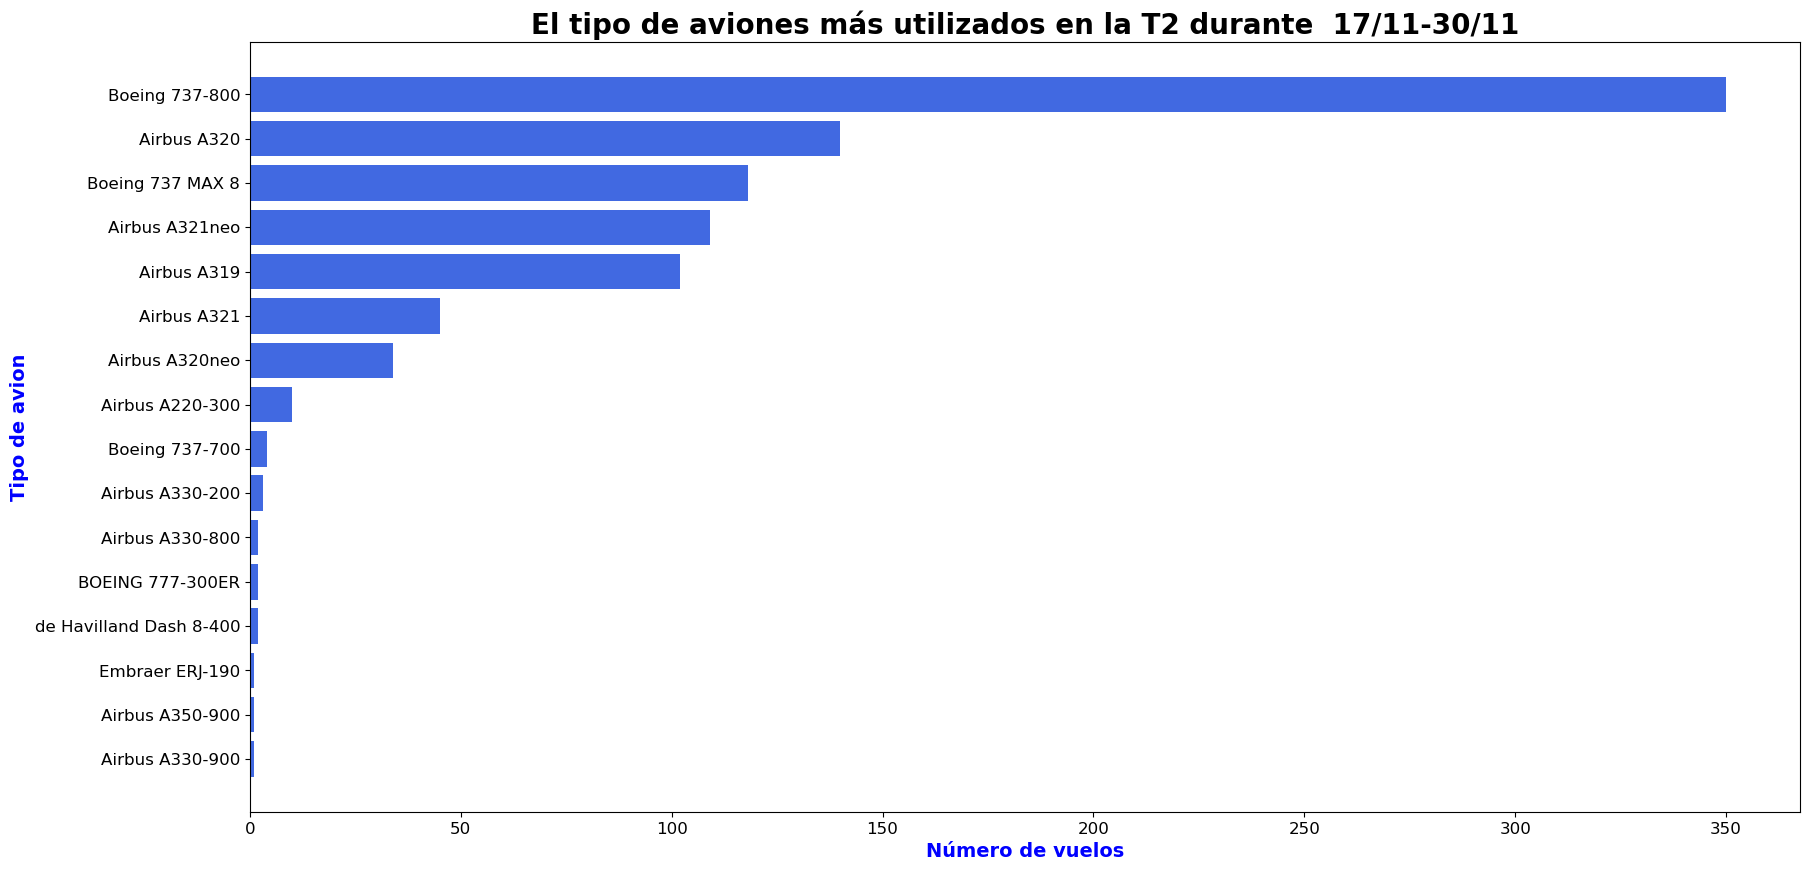

In [47]:
plt.figure(figsize=(20,10))
plt.barh(top40_sorted.index, top40_sorted.values, color="royalblue")

plt.title("El tipo de aviones más utilizados en la T2 durante  17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [48]:
dest_counts = df["Type_f"].value_counts()
top41 = dest_counts.head(30)
top41_sorted = top41.sort_values(ascending=True)

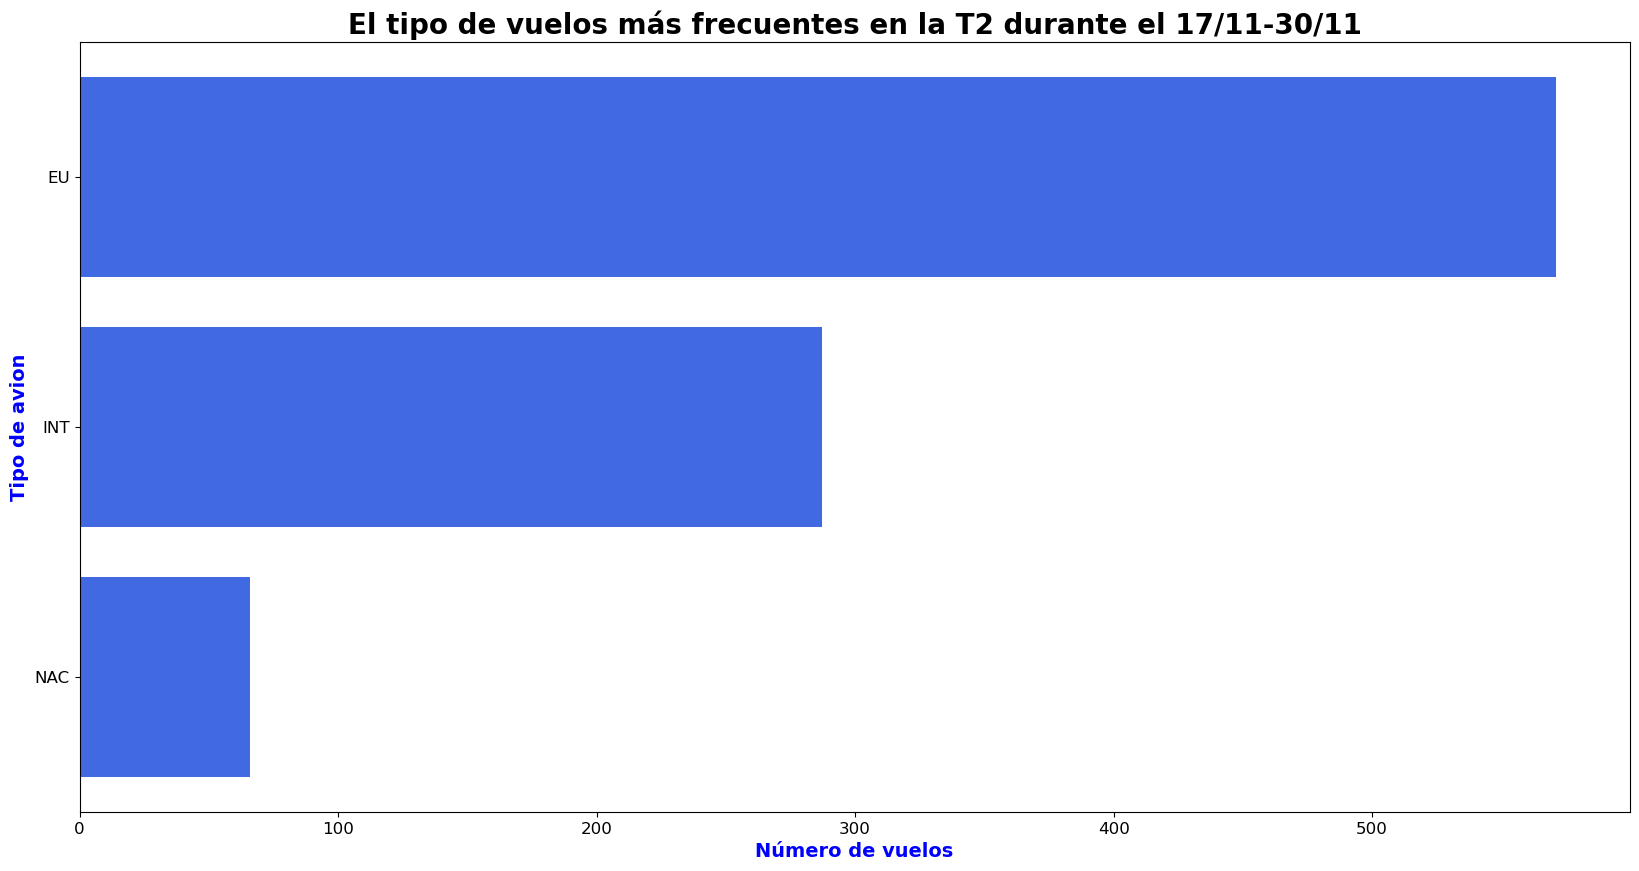

In [49]:
plt.figure(figsize=(20,10))
plt.barh(top41_sorted.index, top41_sorted.values, color="royalblue")

plt.title("El tipo de vuelos más frecuentes en la T2 durante el 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [50]:
df["Type_f"].unique()

array(['EU', 'INT', 'NAC'], dtype=object)

In [51]:
compi = ["Programado", "En hora", "Ha salido"]
easy = ["Retrasado"]

est = []
for x in df['flight_state']:
    if x in compi: 
        est.append("En hora")
    elif x in easy:
        est.append("Retrasado")
print(est)
# objetivo de unificar y estandarizar 

['En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'Retrasado', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'Retrasado', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'Retrasado', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasa

In [52]:
df['flight_state'] = est

In [53]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00,En hora,189,Boeing 737-800,S,EU
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10,En hora,189,Boeing 737-800,S,EU
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15,En hora,156,Airbus A319,R,EU
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20,En hora,189,Boeing 737-800,W,INT
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25,En hora,197,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45,En hora,230,Airbus A321,W,INT
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50,En hora,189,Boeing 737-800,U,EU
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50,En hora,239,Airbus A321neo,S,EU


In [54]:
dest_counts = df["flight_state"].value_counts()
top42 = dest_counts.head(30)
top42_sorted = top42.sort_values(ascending=True)

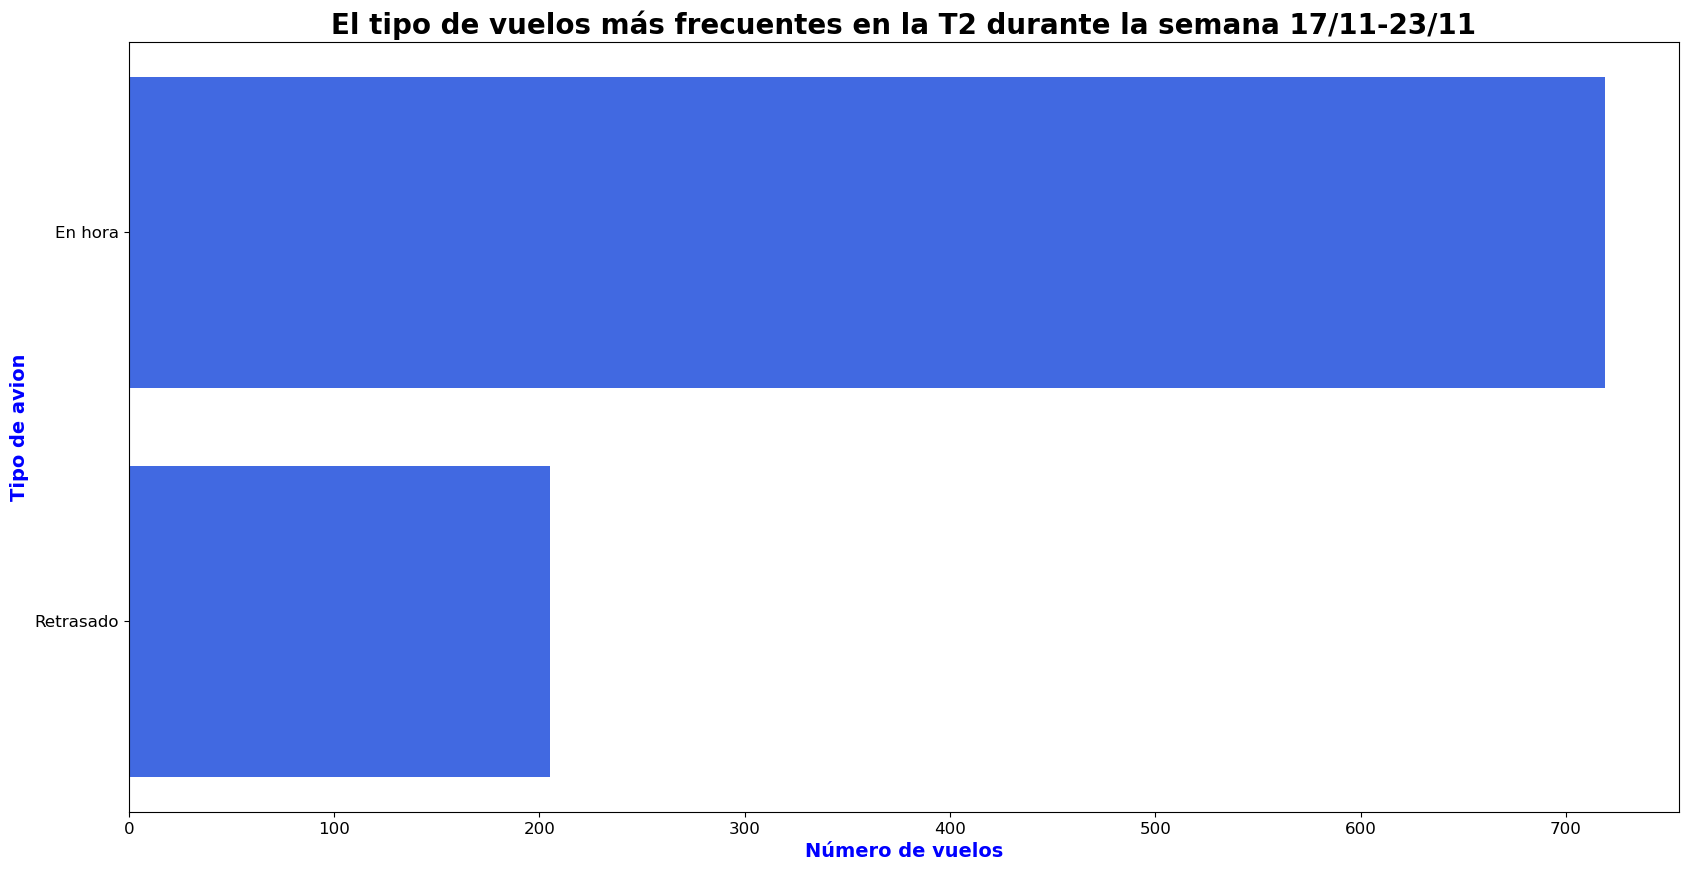

In [55]:
plt.figure(figsize=(20,10))
plt.barh(top42_sorted.index, top42_sorted.values, color="royalblue")

plt.title("El tipo de vuelos más frecuentes en la T2 durante la semana 17/11-23/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

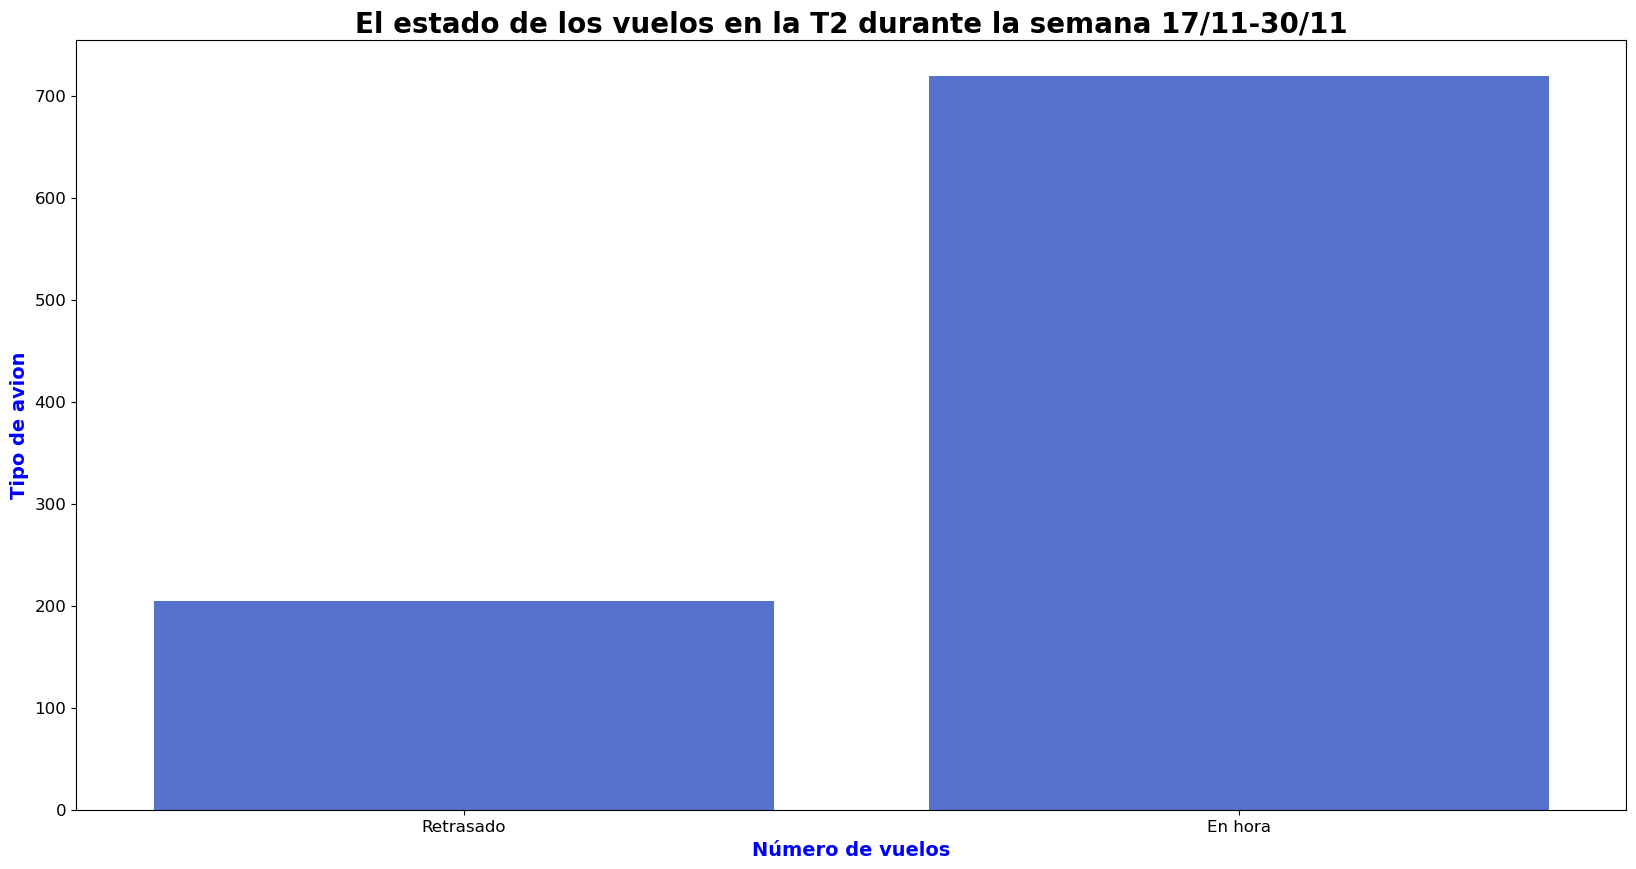

In [56]:
plt.figure(figsize=(20,10))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("El estado de los vuelos en la T2 durante la semana 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [57]:
dest_counts = df["Gate"].value_counts()
top43 = dest_counts.head(30)
top43_sorted = top43.sort_values(ascending=True)

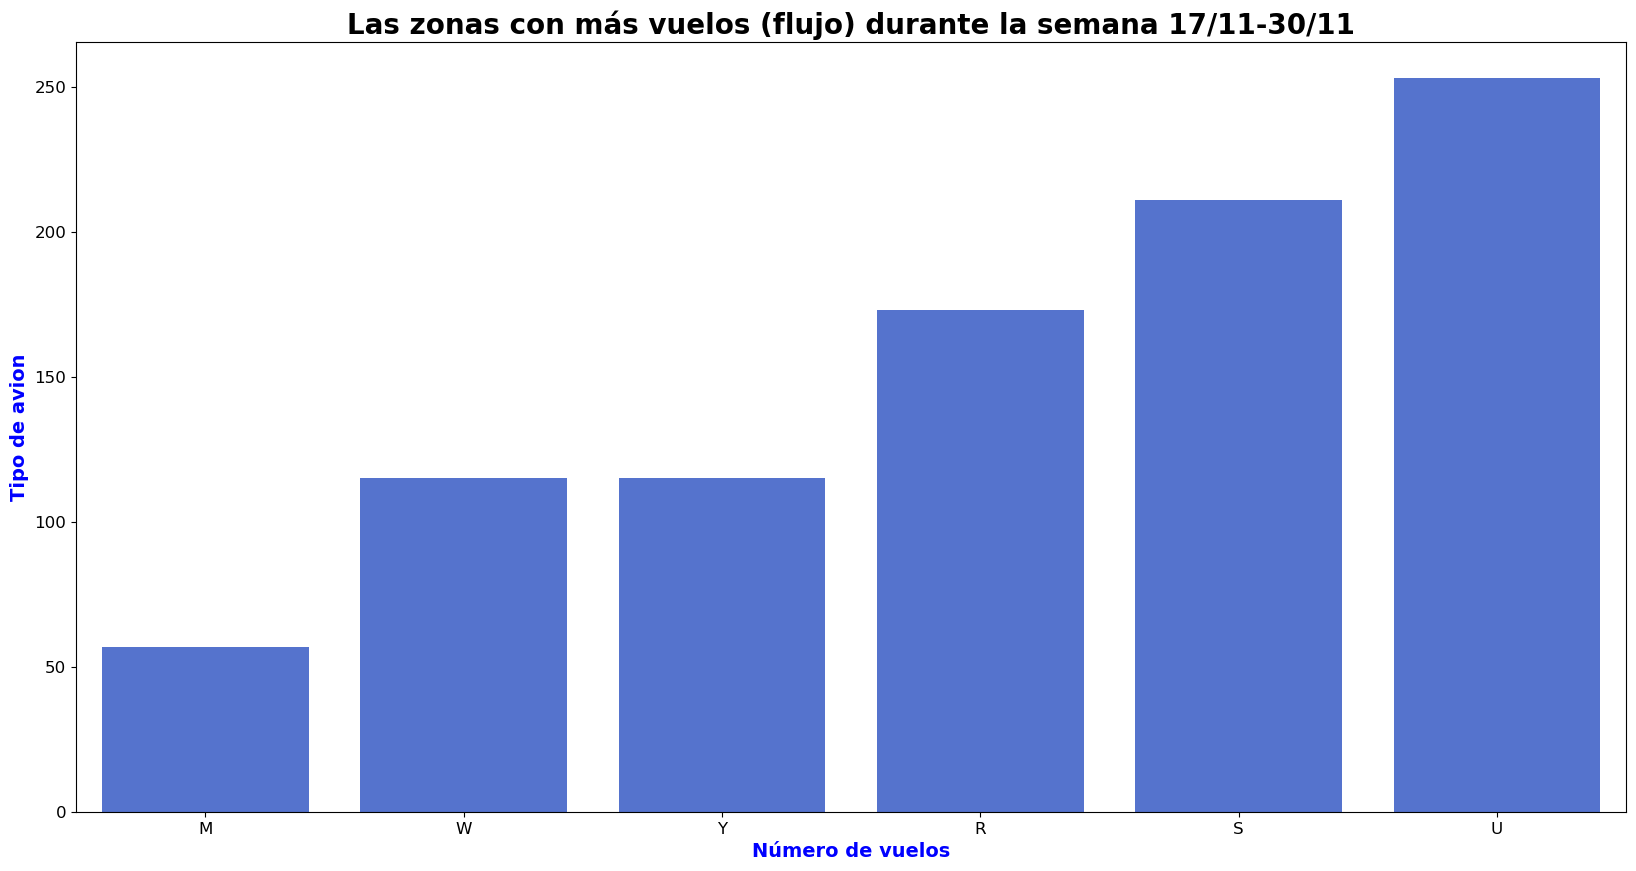

In [58]:
plt.figure(figsize=(20,10))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
sns.barplot(x=top43_sorted.index, y=top43_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("Las zonas con más vuelos (flujo) durante la semana 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [59]:
dest_counts = df["Name_company"].value_counts()
top44 = dest_counts.head(30)
top44_sorted = top44.sort_values(ascending=True)

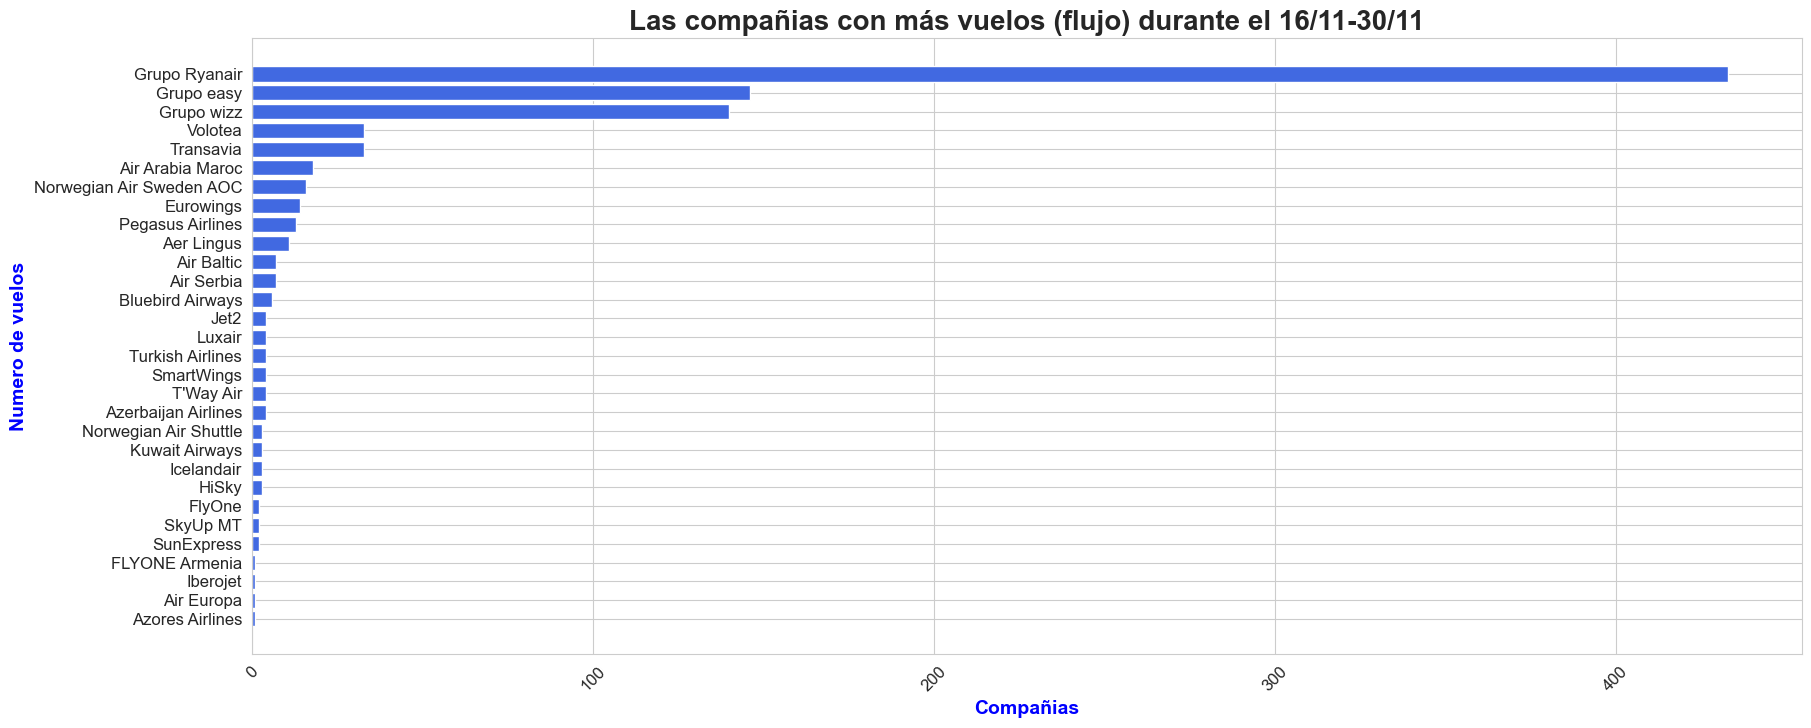

In [60]:
sns.set_style("whitegrid")  # Estilo de fondo
sns.set_palette("tab10") 

plt.figure(figsize=(20,8))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
plt.barh(top44_sorted.index, top44_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("Las compañias con más vuelos (flujo) durante el 16/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Compañias", fontsize=14, weight='bold', color='blue')
plt.ylabel("Numero de vuelos", fontsize=14, weight='bold', color='blue')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [61]:
df['Time_flight'] = pd.to_datetime(df['Time_flight'].astype(str), format="%H:%M").dt.time
#df['hora'] = pd.to_datetime(df['hora'].astype(str), format='%H:%M:%S').dt.time

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha_scrapeo    924 non-null    datetime64[ns]
 1   Name_company     924 non-null    object        
 2   Num_flight       924 non-null    object        
 3   Name_Destiny     924 non-null    object        
 4   Time_flight      924 non-null    object        
 5   flight_state     924 non-null    object        
 6   flight_capacity  924 non-null    Int64         
 7   Aircraft         924 non-null    object        
 8   Gate             924 non-null    object        
 9   Type_f           924 non-null    object        
dtypes: Int64(1), datetime64[ns](1), object(8)
memory usage: 73.2+ KB


In [63]:
# Time_flight      851 non-null    object   convertir en datetime
# añadir columna weed_day

In [64]:
df.head()

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,S,EU
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10:00,En hora,189,Boeing 737-800,S,EU
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,En hora,189,Boeing 737-800,W,INT
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,197,Boeing 737 MAX 8,U,EU


In [65]:
# DEJA EL RESTO DE FILAS EXCESPTO LAS QUE TENGAN ESA FECHA 
#df = df[df['fecha_scrapeo'] != '2025-11-16']

In [66]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,S,EU
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10:00,En hora,189,Boeing 737-800,S,EU
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,En hora,189,Boeing 737-800,W,INT
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,197,Boeing 737 MAX 8,U,EU
...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU


In [67]:
type(df['Time_flight'].iloc[0])

datetime.time

In [68]:
df['week_day'] = df['fecha_scrapeo'].dt.day_name(locale='es_ES')

In [69]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,S,EU,Lunes
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10:00,En hora,189,Boeing 737-800,S,EU,Lunes
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,En hora,189,Boeing 737-800,W,INT,Lunes
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,197,Boeing 737 MAX 8,U,EU,Lunes
...,...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo


In [70]:
dest_counts = df["week_day"].value_counts()

orden_semana = [
    'Lunes', 'Martes', 'Miércoles', 'Jueves',
    'Viernes', 'Sábado', 'Domingo'
]

# Convertimos el índice a categoría ordenada
dest_counts.index = pd.Categorical(dest_counts.index, categories=orden_semana, ordered=True)

# ordenar
top4_sorted = dest_counts.sort_index()


In [71]:
df_counts = df.groupby(["fecha_scrapeo", "week_day"]).size().reset_index(name="n_vuelos")


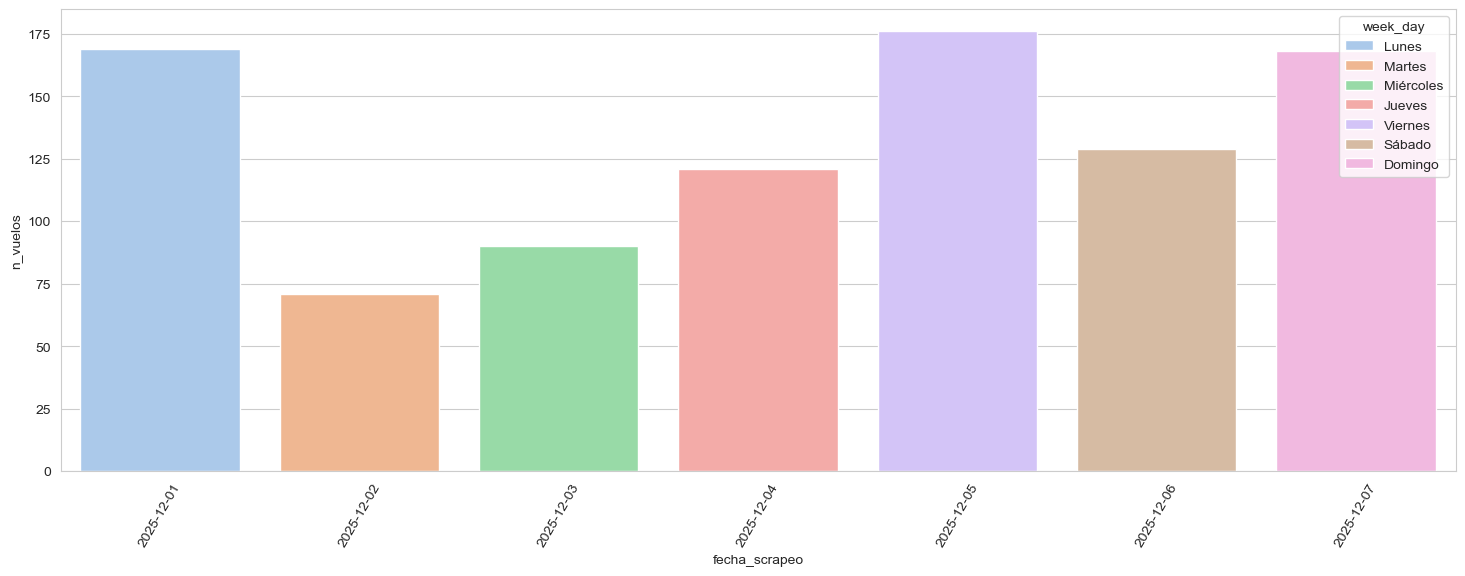

In [72]:
plt.figure(figsize=(18,6))
sns.barplot(
    data=df_counts,
    x="fecha_scrapeo",
    y="n_vuelos",
    hue="week_day",
    palette="pastel"
)
plt.xticks(rotation=60)
plt.show()


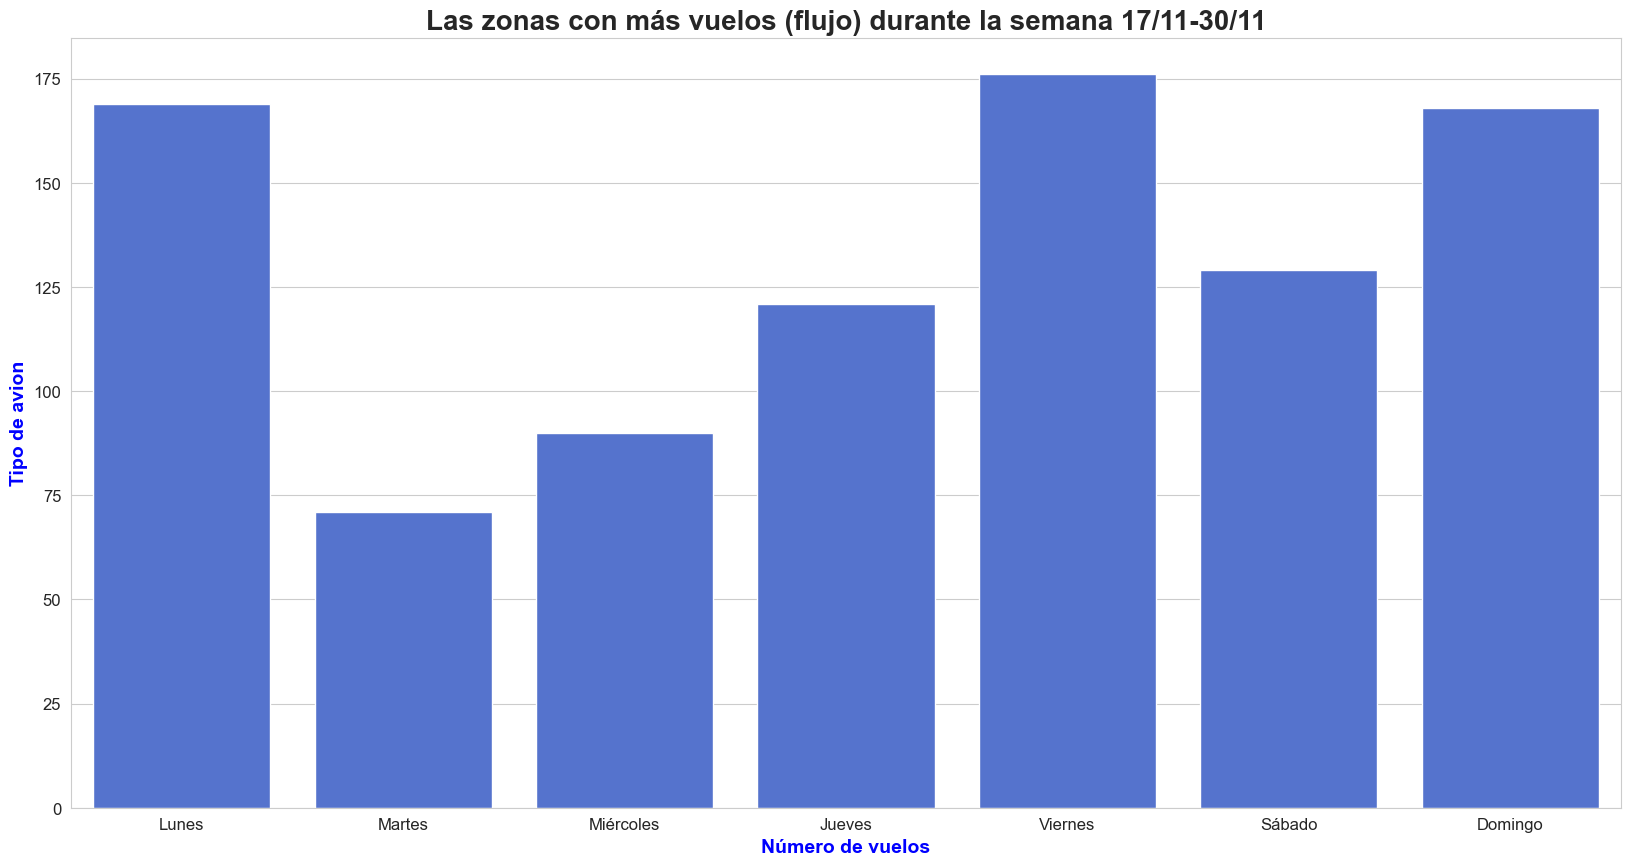

In [73]:
plt.figure(figsize=(20,10))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
sns.barplot(x=top4_sorted.index, y=top4_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("Las zonas con más vuelos (flujo) durante la semana 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [74]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Eurowings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
23,2025-12-01,Eurowings,EW2521,Stuttgart (STR),09:20:00,Retrasado,156,Airbus A319,S,EU,Lunes
286,2025-12-03,Eurowings,EW2521,Stuttgart (STR),15:10:00,En hora,156,Airbus A319,S,EU,Miércoles
778,2025-12-07,Eurowings,EW7521,Hamburg (HAM),09:25:00,En hora,156,Airbus A319,U,EU,Domingo


In [75]:
# CAMBIAR CAPACIDAD A 150 

In [76]:
df.loc[
(df['Aircraft'] == 'Airbus A319') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 150  

In [77]:
df.loc[
(df['Aircraft'] == 'Airbus A320neo') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 180 

In [78]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 180 

In [79]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 226

In [80]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 232

In [81]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Transavia'),
'flight_capacity'
] = 232

In [82]:
df.loc[
(df['Aircraft'] == 'Airbus A319') & 
(df['Name_company'] == 'Air Serbia'),
'flight_capacity'
] = 144 

In [83]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Air Arabia Maroc'),
'flight_capacity'
] = 174   # si es eurowings y tiene ese tipo de avion ponerle estas capacidades 

In [84]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'Pegasus Airlines'),
'flight_capacity'
] = 220   

In [85]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Jet2'),
'flight_capacity'
] = 189

In [86]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Jet2'),
'flight_capacity'
] = 232 

In [87]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Norwegian Air Sweden AOC'),
'flight_capacity'
] = 189

In [88]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Aer Lingus'),
'flight_capacity'
] = 174

In [89]:
df.loc[
(df['Aircraft'] == 'Airbus A220-300') & 
(df['Name_company'] == 'Air Baltic'),
'flight_capacity'
] = 148

In [90]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'Turkish Airlines'),
'flight_capacity'
] = 165

In [91]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Icelandair'),
'flight_capacity'
] = 160

In [92]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'HiSky'),
'flight_capacity'
] = 186

In [93]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'FlyOne'),
'flight_capacity'
] = 194

In [94]:
df.loc[
(df['Aircraft'] == 'Boeing 737-700') & 
(df['Name_company'] == 'Luxair'),
'flight_capacity'
] = 141

In [95]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'Luxair'),
'flight_capacity'
] = 186

In [96]:
df.loc[
(df['Aircraft'] == 'Airbus A330-200') & 
(df['Name_company'] == 'Boliviana de Aviacion'),
'flight_capacity'
] = 246

In [97]:
df.loc[
(df['Aircraft'] == 'Airbus A350-900') & 
(df['Name_company'] == 'Iberojet'),
'flight_capacity'
] = 432

In [98]:
df.loc[
(df['Aircraft'] == 'Airbus A320neo') & 
(df['Name_company'] == 'Azores Airlines'),
'flight_capacity'
] = 186

In [99]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'FLYONE Armenia'),
'flight_capacity'
] = 180

In [100]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'FlyOne'),
'flight_capacity'
] = 180

In [101]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'FlyOne'),
'flight_capacity'
] = 194

In [102]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'HiSky'),
'flight_capacity'
] = 186

In [103]:
df.loc[
(df['Aircraft'] == 'Boeing 737-700') & 
(df['Name_company'] == 'SkyUp MT'),
'flight_capacity'
] = 149

In [104]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'SunExpress'),
'flight_capacity'
] = 189

In [105]:
df.loc[
(df['Aircraft'] == 'Boeing 757-200') & 
(df['Name_company'] == 'Icelandair'),
'flight_capacity'
] = 184

In [106]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Icelandair'),
'flight_capacity'
] = 160

In [107]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'Turkish Airlines'),
'flight_capacity'
] = 165

In [108]:
df.loc[
(df['Aircraft'] == 'Airbus A319') & 
(df['Name_company'] == 'Azerbaijan Airlines'),
'flight_capacity'
] = 122

In [109]:
df.loc[
(df['Aircraft'] == 'Airbus A320neo') & 
(df['Name_company'] == 'Azerbaijan Airlines'),
'flight_capacity'
] = 186

In [110]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Azerbaijan Airlines'),
'flight_capacity'
] = 174

In [111]:
df[(df['Aircraft'] == 'DBoeing 737-800')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [112]:
df['Aircraft'].unique()

array(['Boeing 737-800', 'Airbus A319', 'Boeing 737 MAX 8', 'Airbus A320',
       'Airbus A321neo', 'Airbus A321', 'Airbus A320neo',
       'de Havilland Dash 8-400', 'Airbus A220-300', 'Airbus A330-200',
       'Airbus A330-900', 'Boeing 737-700', 'Airbus A350-900',
       'BOEING 777-300ER', 'Embraer ERJ-190', 'Airbus A330-800'],
      dtype=object)

In [113]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,S,EU,Lunes
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10:00,En hora,189,Boeing 737-800,S,EU,Lunes
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,En hora,189,Boeing 737-800,W,INT,Lunes
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,197,Boeing 737 MAX 8,U,EU,Lunes
...,...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo


In [114]:
df[(df['Name_company'] == 'Grupo wizz')]['Aircraft'].value_counts()
# contabilizar que aviones son más utilizados por esta compañía

Aircraft
Airbus A321neo    93
Airbus A321       31
Airbus A320       15
Airbus A320neo     1
Name: count, dtype: int64

In [115]:
df[(df['Name_company'] == 'Grupo easy') & (df['Aircraft'] == 'Boeing 737 MAX 8')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [116]:
df[(df['Name_company'] == 'Grupo easy') & (df['Num_flight'] == 'EC8064')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
204,2025-12-02,Grupo easy,EC8064,London (LGW),12:25:00,En hora,156,Airbus A319,M,INT,Martes
374,2025-12-04,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Jueves
511,2025-12-05,Grupo easy,EC8064,London (LGW),12:15:00,En hora,156,Airbus A319,M,INT,Viernes
677,2025-12-06,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado
764,2025-12-07,Grupo easy,EC8064,London (LGW),07:20:00,En hora,156,Airbus A319,M,INT,Domingo


In [117]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] != 'M') & (df['Type_f'] == 'INT')]
# de easyjet que el vuelo sea int y que su gate no sea M 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [118]:
df.loc[
(df['Name_company'] == 'Grupo easy') & 
(df['Gate'] != 'M') &
(df['Type_f'] == 'INT'),
'Gate'
] = 'M'

In [119]:
df[(df['fecha_scrapeo'] == '2025-11-21') & (df['Num_flight'] == 'EC7139')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [120]:
#  Airbus A319
df.loc[
(df['fecha_scrapeo'] == '2025-11-21') & 
(df['Num_flight'] == 'EC8064'),
'Aircraft'
] = 'Airbus A319'
df.loc[
(df['fecha_scrapeo'] == '2025-11-21') & 
(df['Num_flight'] == 'EC8064'),
'flight_capacity'
] = 156

#df.loc[df['Num_flight'] == 'EC8064', 'flight_capacity'] = 156

In [121]:
df[(df['Name_company'] == 'Grupo easy')]['Aircraft'].value_counts()

Aircraft
Airbus A319       81
Airbus A320       41
Airbus A320neo    18
Airbus A321        6
Name: count, dtype: int64

In [122]:
df[(df['Aircraft'].isna())]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [123]:
#df.drop(df.index[125], inplace=True) # avion de cargo 

In [124]:
df.reset_index(drop=True, inplace=True)

In [125]:
df[(df['Aircraft'].isna())]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [126]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,S,EU,Lunes
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10:00,En hora,189,Boeing 737-800,S,EU,Lunes
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,En hora,189,Boeing 737-800,W,INT,Lunes
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,197,Boeing 737 MAX 8,U,EU,Lunes
...,...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo


In [127]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
dtype: int64

In [128]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [129]:
# IMPUTACION PARA MI AIRCRAFT / FLIGHT CAPACITY 

## Imputación por el 'modus operandis': 
- El aircraft depende en su mayoría del tipo de aerolinea y la capacidad aeerea depende del aircraft.
- Con una imputación de KNN o Moda sería más impreciso, y podría coger un tipo de avion de otros vecinos que esa compañia no utiliza.
- Por lo tanto escojo el avión más frecuente de esa aerolínea y de esa manera me quedo en el rango de su flota. 

In [130]:
"""
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'W45154'),
'Aircraft'
] = 'Airbus A321neo'
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'W45154'),
'flight_capacity'
] = 239
# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION 
"""

"\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-23') & \n(df['Num_flight'] == 'W45154'),\n'Aircraft'\n] = 'Airbus A321neo'\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-23') & \n(df['Num_flight'] == 'W45154'),\n'flight_capacity'\n] = 239\n# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION \n"

In [131]:
"""
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'EC7139'),
'Aircraft'
] = 'Airbus A319'
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'EC7139'),
'flight_capacity'
] = 156
# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION 
"""

"\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-23') & \n(df['Num_flight'] == 'EC7139'),\n'Aircraft'\n] = 'Airbus A319'\ndf.loc[\n(df['fecha_scrapeo'] == '2025-11-23') & \n(df['Num_flight'] == 'EC7139'),\n'flight_capacity'\n] = 156\n# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION \n"

In [132]:
# Para easy es el Airbus A319
# para wizz Airbus A321neo 

In [133]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
dtype: int64

In [134]:
df[(df['fecha_scrapeo'] == '2025-11-23') & (df['Num_flight'] == 'EC7139')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [135]:
df[(df['Num_flight'] == 'EC7139')]
# 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
411,2025-12-04,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),18:15:00,En hora,156,Airbus A319,R,EU,Jueves
808,2025-12-07,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,156,Airbus A319,R,EU,Domingo


In [136]:
df[(df['Num_flight'] == 'EC8064')] #VEO OTRO NUMERO DE VUELO DE EASYJET 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
204,2025-12-02,Grupo easy,EC8064,London (LGW),12:25:00,En hora,156,Airbus A319,M,INT,Martes
374,2025-12-04,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Jueves
511,2025-12-05,Grupo easy,EC8064,London (LGW),12:15:00,En hora,156,Airbus A319,M,INT,Viernes
677,2025-12-06,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado
764,2025-12-07,Grupo easy,EC8064,London (LGW),07:20:00,En hora,156,Airbus A319,M,INT,Domingo


In [137]:
# AHORA QUIERO SABER CUANTOS NUMEROS DE VUELO TIENE EASY EN GENERAL

In [138]:
df[(df['Name_company'] == 'Grupo easy')]['Num_flight'].unique()

array(['EC7105', 'EC8062', 'EC7141', 'EC7151', 'EC1376', 'EC1030',
       'EC7656', 'U22324', 'EC7131', 'U28056', 'U22002', 'EC7197',
       'EC7137', 'EC7153', 'EC7107', 'EC4212', 'U23372', 'EC7173',
       'EC3737', 'EC7199', 'EC7205', 'U28058', 'EC1956', 'EC1010',
       'EC1380', 'U22706', 'EC7682', 'EC7101', 'EC8064', 'EC7103',
       'EC7193', 'EC7161', 'U22704', 'EC8060', 'EC7155', 'U22326',
       'EC7191', 'U25716', 'EC1378', 'EC7139', 'U26654', 'EC7694',
       'U23374', 'U28060', 'EC8066', 'EC3754', 'EC7109', 'EC7159',
       'EC3750'], dtype=object)

In [139]:
df_easy = df[df['Name_company'] == 'Grupo easy']

In [140]:
df_counts = (
    df_easy
    .groupby(['Num_flight', 'Aircraft'])
    .size()
    .reset_index(name='count')
)

In [141]:
df_counts

,Num_flight,Aircraft,count
0,EC1010,Airbus A319,1
1,EC1030,Airbus A320,1
2,EC1376,Airbus A319,3
3,EC1378,Airbus A320,1
4,EC1380,Airbus A320,7
...,...,...,...
57,U28058,Airbus A319,2
58,U28058,Airbus A320,3
59,U28058,Airbus A320neo,1
60,U28060,Airbus A319,1


In [142]:
df_top_aircraft = (
    df_counts
    .sort_values(['Num_flight', 'count'], ascending=[True, False])
    .groupby('Num_flight')
    .first()
    .reset_index()
)

In [143]:
df_top_aircraft


,Num_flight,Aircraft,count
0,EC1010,Airbus A319,1
1,EC1030,Airbus A320,1
2,EC1376,Airbus A319,3
3,EC1378,Airbus A320,1
4,EC1380,Airbus A320,7
5,EC1956,Airbus A320,5
6,EC3737,Airbus A319,3
7,EC3750,Airbus A320,1
8,EC3754,Airbus A320,1
9,EC4212,Airbus A320,4


In [144]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
dtype: int64

## Imputación por categorías naturales para Gate
- el Gate depende del tipo de vuelo(nacional, int, EU), la compañia (easyjet o FR) y el destino.

In [145]:
v = df.groupby(['Gate', 'Type_f']).size().reset_index(name='count')
v.sort_values(['Type_f'])

,Gate,Type_f,count
1,R,EU,160
3,S,EU,182
5,U,EU,229
0,M,INT,57
7,W,INT,115
8,Y,INT,115
2,R,NAC,13
4,S,NAC,29
6,U,NAC,24


In [146]:
v = df.groupby(['Gate', 'Type_f', 'Name_company']).size().reset_index(name='count')
v[(v['Name_company'] == 'Grupo Ryanair')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
2,R,EU,Grupo Ryanair,33
14,S,EU,Grupo Ryanair,94
26,U,EU,Grupo Ryanair,128
44,W,INT,Grupo Ryanair,60
60,Y,INT,Grupo Ryanair,63
10,R,NAC,Grupo Ryanair,9
21,S,NAC,Grupo Ryanair,25
35,U,NAC,Grupo Ryanair,21


In [147]:
v[(v['Name_company'] == 'Grupo easy')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
3,R,EU,Grupo easy,89
0,M,INT,Grupo easy,57


In [148]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] == 'S')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [149]:
df[(df['Name_company'] == 'Grupo easy') & (df['Name_Destiny'] == 'Geneva (GVA)')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
17,2025-12-01,Grupo easy,EC1376,Geneva (GVA),08:45:00,En hora,156,Airbus A319,R,EU,Lunes
83,2025-12-01,Grupo easy,EC7107,Geneva (GVA),14:45:00,En hora,156,Airbus A319,R,EU,Lunes
152,2025-12-01,Grupo easy,EC1380,Geneva (GVA),21:20:00,En hora,180,Airbus A320,R,EU,Lunes
169,2025-12-02,Grupo easy,EC7105,Geneva (GVA),06:00:00,En hora,156,Airbus A319,R,EU,Martes
236,2025-12-02,Grupo easy,EC1380,Geneva (GVA),21:15:00,Retrasado,180,Airbus A320,R,EU,Martes
243,2025-12-03,Grupo easy,EC7105,Geneva (GVA),06:10:00,En hora,156,Airbus A319,R,EU,Miércoles
326,2025-12-03,Grupo easy,EC1380,Geneva (GVA),21:15:00,Retrasado,180,Airbus A320,R,EU,Miércoles
331,2025-12-04,Grupo easy,EC7105,Geneva (GVA),06:10:00,En hora,156,Airbus A319,R,EU,Jueves
405,2025-12-04,Grupo easy,EC1378,Geneva (GVA),16:50:00,Retrasado,180,Airbus A320,R,EU,Jueves


In [150]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] == 'U')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [151]:
v[(v['Name_company'] == 'Grupo wizz')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
4,R,EU,Grupo wizz,11
15,S,EU,Grupo wizz,49
27,U,EU,Grupo wizz,57
45,W,INT,Grupo wizz,17
61,Y,INT,Grupo wizz,6


In [152]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Gate'] == 'R')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
97,2025-12-01,Grupo wizz,W43564,Timisoara (TSR),16:25:00,Retrasado,180,Airbus A320,R,EU,Lunes
117,2025-12-01,Grupo wizz,W43686,Iasi (IAS),18:30:00,En hora,180,Airbus A320,R,EU,Lunes
125,2025-12-01,Grupo wizz,W61706,Gdansk (GDN),19:40:00,En hora,230,Airbus A321,R,EU,Lunes
144,2025-12-01,Grupo wizz,W62378,Budapest (BUD),20:45:00,En hora,239,Airbus A321neo,R,EU,Lunes
154,2025-12-01,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,180,Airbus A320,R,EU,Lunes
224,2025-12-02,Grupo wizz,W61176,Katowice (KTW),18:55:00,En hora,239,Airbus A321neo,R,EU,Martes
226,2025-12-02,Grupo wizz,W43180,Bucharest (OTP),19:20:00,En hora,230,Airbus A321,R,EU,Martes
792,2025-12-07,Grupo wizz,W46018,Rome (FCO),10:00:00,En hora,239,Airbus A321neo,R,EU,Domingo
874,2025-12-07,Grupo wizz,W61176,Katowice (KTW),18:55:00,En hora,180,Airbus A320,R,EU,Domingo
877,2025-12-07,Grupo wizz,W43180,Bucharest (OTP),19:05:00,Retrasado,230,Airbus A321,R,EU,Domingo


In [153]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Num_flight'] == 'W43180')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
226,2025-12-02,Grupo wizz,W43180,Bucharest (OTP),19:20:00,En hora,230,Airbus A321,R,EU,Martes
415,2025-12-04,Grupo wizz,W43180,Bucharest (OTP),18:45:00,En hora,230,Airbus A321,S,EU,Jueves
714,2025-12-06,Grupo wizz,W43180,Bucharest (OTP),17:40:00,En hora,230,Airbus A321,S,EU,Sábado
877,2025-12-07,Grupo wizz,W43180,Bucharest (OTP),19:05:00,Retrasado,230,Airbus A321,R,EU,Domingo


In [154]:
"""
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Num_flight'] == 'W43180') &
(df['fecha_scrapeo'] == '2025-11-23'),
'Gate'
] = 'U'
"""

"\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Num_flight'] == 'W43180') &\n(df['fecha_scrapeo'] == '2025-11-23'),\n'Gate'\n] = 'U'\n"

In [155]:
v[(v['Name_company'] == 'Transavia')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
8,R,EU,Transavia,4
19,S,EU,Transavia,12
33,U,EU,Transavia,17


In [156]:
df[(df['Name_company'] == 'Transavia') & (df['Type_f'] == 'INT')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [157]:
df[(df['Name_company'] == 'Transavia') & (df['Gate'] == 'R')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
54,2025-12-01,Transavia,TO4755,Paris (ORY),11:30:00,Retrasado,189,Boeing 737-800,R,EU,Lunes
358,2025-12-04,Transavia,HV5132,Amsterdam (AMS),10:05:00,En hora,232,Airbus A321neo,R,EU,Jueves
657,2025-12-06,Transavia,HV5132,Amsterdam (AMS),10:05:00,En hora,232,Airbus A321neo,R,EU,Sábado
730,2025-12-06,Transavia,TO4757,Paris (ORY),19:25:00,Retrasado,186,Airbus A320neo,R,EU,Sábado


In [158]:
"""
df.loc[
(df['Name_company'] == 'Transavia') & 
(df['Type_f'] == 'INT'),
'Gate'
] = 'U'
df.loc[
(df['Name_company'] == 'Transavia') & 
(df['Type_f'] == 'INT'),
'Type_f'
] = 'EU'
"""

"\ndf.loc[\n(df['Name_company'] == 'Transavia') & \n(df['Type_f'] == 'INT'),\n'Gate'\n] = 'U'\ndf.loc[\n(df['Name_company'] == 'Transavia') & \n(df['Type_f'] == 'INT'),\n'Type_f'\n] = 'EU'\n"

In [159]:
# En general se puede ver que en vuelos EU hay una frecuencia + alta
# en asignar la puerta U, S y despues R.
# Vuelos 

In [160]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Gate'] == 'M')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [161]:
"""
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Gate'] == 'M'),
'Type_f'
] = 'EU'
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Gate'] == 'M'),
'Gate'
] = 'U'
"""

"\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Gate'] == 'M'),\n'Type_f'\n] = 'EU'\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Gate'] == 'M'),\n'Gate'\n] = 'U'\n"

In [162]:
df[(df['Name_company'] == 'Air Arabia Maroc') & (df['Gate'] == 'S')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [163]:
df[(df['Gate'].isna())].sort_values(['Name_company']).sort_values(['Type_f'])

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [164]:
#df[(df['Num_flight'] == 'W43178')]

In [165]:
"""
df.loc[df['Name_company'] == 'Air Arabia Maroc', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'W43178', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W43686', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W62378', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'FR2233', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'FR9406', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'FR1681', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'FR777', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'TO4755', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'TO4751', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W62096', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W45154', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'W61914', 'Type_f'] = 'EU'
"""

"\ndf.loc[df['Name_company'] == 'Air Arabia Maroc', 'Type_f'] = 'INT'\ndf.loc[df['Num_flight'] == 'W43178', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'W43686', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'W62378', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'FR2233', 'Type_f'] = 'INT'\ndf.loc[df['Num_flight'] == 'FR9406', 'Type_f'] = 'INT'\ndf.loc[df['Num_flight'] == 'FR1681', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'FR777', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'TO4755', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'TO4751', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'W62096', 'Type_f'] = 'EU'\ndf.loc[df['Num_flight'] == 'W45154', 'Type_f'] = 'INT'\ndf.loc[df['Num_flight'] == 'W61914', 'Type_f'] = 'EU'\n"

In [166]:
v[(v['Name_company'] == 'Air Arabia Maroc')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
38,W,INT,Air Arabia Maroc,1
54,Y,INT,Air Arabia Maroc,17


In [167]:
df[(df['Name_company'] == 'Air Arabia Maroc') & (df['Gate'] == 'W')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
637,2025-12-06,Air Arabia Maroc,3O376,Al Aaroui (NDR),08:35:00,En hora,174,Airbus A320,W,INT,Sábado


In [168]:
v[(v['Name_company'] == 'Grupo Ryanair')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
2,R,EU,Grupo Ryanair,33
14,S,EU,Grupo Ryanair,94
26,U,EU,Grupo Ryanair,128
44,W,INT,Grupo Ryanair,60
60,Y,INT,Grupo Ryanair,63
10,R,NAC,Grupo Ryanair,9
21,S,NAC,Grupo Ryanair,25
35,U,NAC,Grupo Ryanair,21


In [169]:
v[(v['Name_company'] == 'Grupo wizz')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
4,R,EU,Grupo wizz,11
15,S,EU,Grupo wizz,49
27,U,EU,Grupo wizz,57
45,W,INT,Grupo wizz,17
61,Y,INT,Grupo wizz,6


In [170]:
v[(v['Name_company'] == 'Transavia')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
8,R,EU,Transavia,4
19,S,EU,Transavia,12
33,U,EU,Transavia,17


In [171]:
df[(df['Name_company'] == 'Transavia') & (df['Gate'] == 'R')]# ES CORRECTO 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
54,2025-12-01,Transavia,TO4755,Paris (ORY),11:30:00,Retrasado,189,Boeing 737-800,R,EU,Lunes
358,2025-12-04,Transavia,HV5132,Amsterdam (AMS),10:05:00,En hora,232,Airbus A321neo,R,EU,Jueves
657,2025-12-06,Transavia,HV5132,Amsterdam (AMS),10:05:00,En hora,232,Airbus A321neo,R,EU,Sábado
730,2025-12-06,Transavia,TO4757,Paris (ORY),19:25:00,Retrasado,186,Airbus A320neo,R,EU,Sábado


In [172]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,S,EU,Lunes
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10:00,En hora,189,Boeing 737-800,S,EU,Lunes
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,En hora,189,Boeing 737-800,W,INT,Lunes
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,197,Boeing 737 MAX 8,U,EU,Lunes
...,...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo


In [173]:
df['Hora_dt'] = pd.to_datetime(df['Time_flight'].astype(str), format='%H:%M:%S')

df['day_time'] = np.where(df['Hora_dt'].dt.hour.between(6, 11), 'Mañana',
                np.where(df['Hora_dt'].dt.hour.between(12, 19), 'Tarde',
                'Noche'))

In [174]:
df = df.drop(columns=['Hora_dt'])

In [175]:
dest_counts = df["day_time"].value_counts()
top5 = dest_counts.head(30)
orden = ['Mañana', 'Tarde', 'Noche']
top5_sorted = top5.reindex(orden)

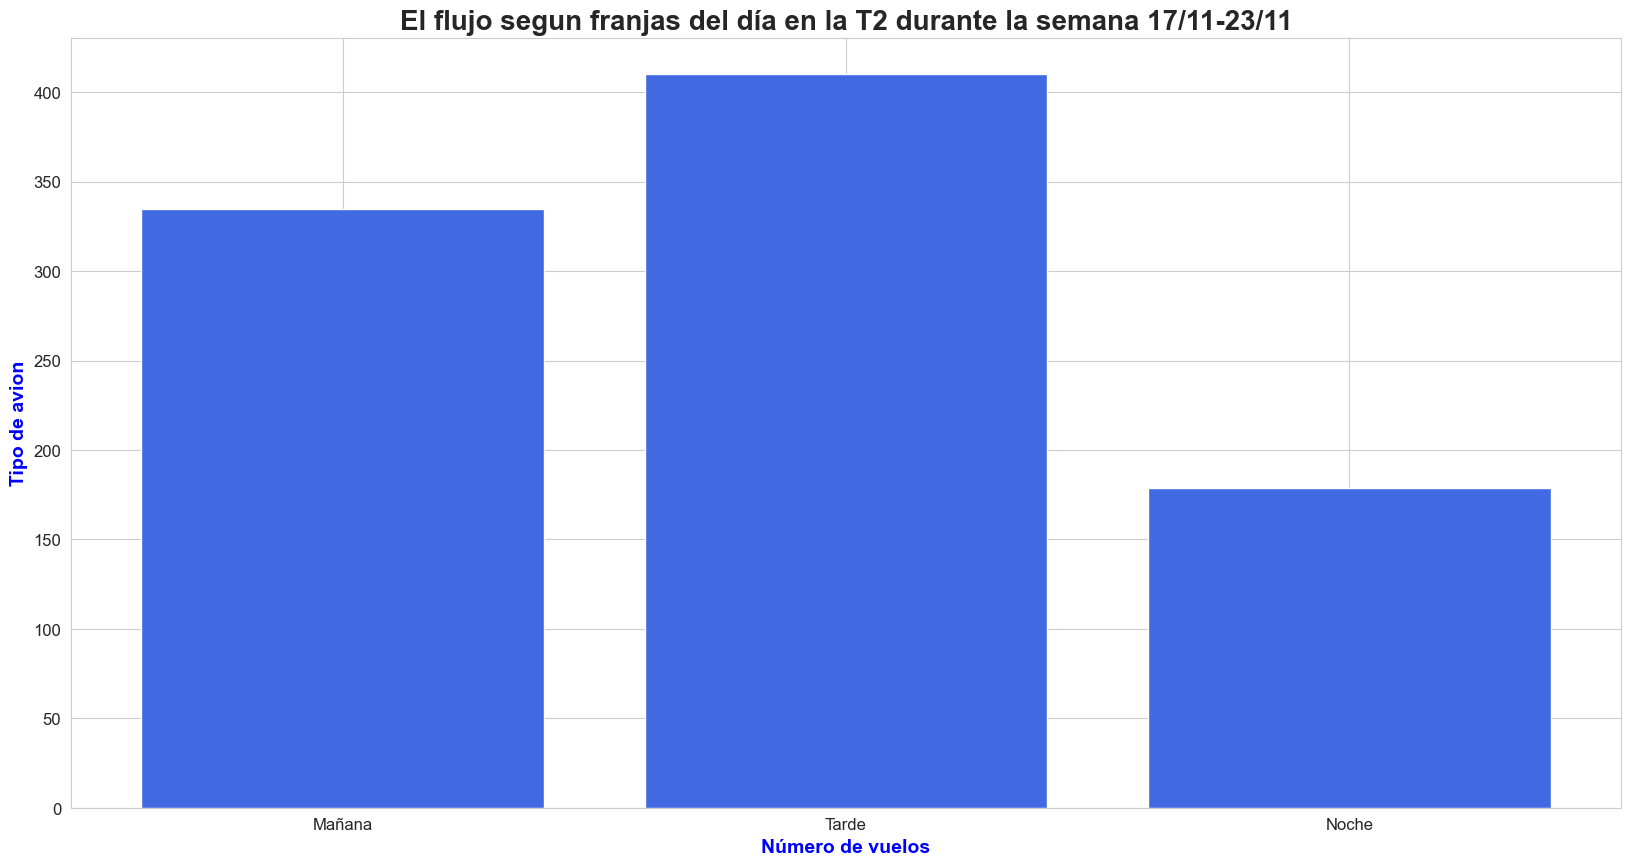

In [176]:
plt.figure(figsize=(20,10))
plt.bar(top5_sorted.index, top5_sorted.values, color="royalblue")

plt.title("El flujo segun franjas del día en la T2 durante la semana 17/11-23/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [177]:
#df.to_csv("vuelos_semanal_limpio1.csv") 

In [178]:
# Ver la capacidad

In [179]:
df_cn = (
    df_easy
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_cn
# ARREGLAR A319 PARA QUE SU CAPACIDAD SEA 156

,Name_company,Aircraft,flight_capacity,count
0,Grupo easy,Airbus A319,156,81
1,Grupo easy,Airbus A320,180,41
2,Grupo easy,Airbus A320neo,186,18
3,Grupo easy,Airbus A321,230,6


In [180]:
df[(df['Aircraft'] == 'Boeing 737-800') & (df['Name_company'] == 'Grupo easy') &
(df['flight_capacity'] == 189)]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [181]:
df_wizz = df[df['Name_company'] == 'Grupo wizz']

In [182]:
df_cw = (
    df_wizz
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

# Corregido
df_cw

,Name_company,Aircraft,flight_capacity,count
0,Grupo wizz,Airbus A320,180,15
1,Grupo wizz,Airbus A320neo,186,1
2,Grupo wizz,Airbus A321,230,31
3,Grupo wizz,Airbus A321neo,239,93


In [183]:
df[(df['Aircraft'] == 'Airbus A320neo') & (df['Name_company'] == 'Grupo wizz') &
(df['flight_capacity'] == 186)]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
327,2025-12-03,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,186,Airbus A320neo,S,EU,Miércoles,Noche


In [184]:
df_ryr = df[df['Name_company'] == 'Grupo Ryanair']

In [185]:
df_cy = (
    df_ryr
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_cy
# CorregiFR3180do!

,Name_company,Aircraft,flight_capacity,count
0,Grupo Ryanair,Airbus A320,180,19
1,Grupo Ryanair,Boeing 737 MAX 8,197,110
2,Grupo Ryanair,Boeing 737-800,189,304


In [186]:
df[(df['flight_capacity'] == 156) & (df['Name_company'] == 'Grupo Ryanair')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [187]:
df_t = df[df['Name_company'] == 'Transavia']

In [188]:
df_tr = (
    df_t
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_tr

,Name_company,Aircraft,flight_capacity,count
0,Transavia,Airbus A320neo,186,11
1,Transavia,Airbus A321neo,232,7
2,Transavia,Boeing 737-800,189,15


In [189]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Transavia')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [190]:
df_v = df[df['Name_company'] == 'Volotea']

In [191]:
df_vl = (
    df_v
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_vl
# CORREGIdo !

,Name_company,Aircraft,flight_capacity,count
0,Volotea,Airbus A319,156,11
1,Volotea,Airbus A320,180,22


In [192]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Volotea')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
21,2025-12-01,Volotea,V72327,Strasbourg (SXB),09:10:00,Retrasado,156,Airbus A319,R,EU,Lunes,Mañana
27,2025-12-01,Volotea,V73573,Asturias (OVD),09:30:00,En hora,156,Airbus A319,S,NAC,Lunes,Mañana
107,2025-12-01,Volotea,V73700,Vitoria (VIT),17:15:00,En hora,156,Airbus A319,S,NAC,Lunes,Tarde
147,2025-12-01,Volotea,V72165,Nantes/Atlantique (NTE),20:50:00,En hora,156,Airbus A319,R,EU,Lunes,Noche
400,2025-12-04,Volotea,V73573,Asturias (OVD),16:05:00,En hora,156,Airbus A319,R,NAC,Jueves,Tarde
543,2025-12-05,Volotea,V73735,Murcia (RMU),15:15:00,En hora,156,Airbus A319,U,NAC,Viernes,Tarde
560,2025-12-05,Volotea,V73573,Asturias (OVD),17:40:00,En hora,156,Airbus A319,U,NAC,Viernes,Tarde
576,2025-12-05,Volotea,V72165,Nantes/Atlantique (NTE),19:30:00,En hora,156,Airbus A319,S,EU,Viernes,Tarde
811,2025-12-07,Volotea,V72327,Strasbourg (SXB),11:55:00,En hora,156,Airbus A319,S,EU,Domingo,Mañana
860,2025-12-07,Volotea,V73573,Asturias (OVD),17:40:00,En hora,156,Airbus A319,S,NAC,Domingo,Tarde


In [193]:
df_e = df[df['Name_company'] == 'Eurowings']

In [194]:
df_ew = (
    df_e
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ew


,Name_company,Aircraft,flight_capacity,count
0,Eurowings,Airbus A319,150,3
1,Eurowings,Airbus A320,180,6
2,Eurowings,Airbus A321,226,1
3,Eurowings,Airbus A321neo,232,4


In [195]:
df[(df['Aircraft'] == 'Airbus A321') & (df['Name_company'] == 'Eurowings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
31,2025-12-01,Eurowings,EW9441,Dusseldorf (DUS),09:45:00,En hora,226,Airbus A321,R,EU,Lunes,Mañana


In [196]:
df_p = df[df['Name_company'] == 'Pegasus Airlines']

In [197]:
df_pg = (
    df_p
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_pg


,Name_company,Aircraft,flight_capacity,count
0,Pegasus Airlines,Airbus A320,180,3
1,Pegasus Airlines,Airbus A321,220,5
2,Pegasus Airlines,Airbus A321neo,239,5


In [198]:
df[(df['Aircraft'] == 'Boeing 737-800') & (df['Name_company'] == 'Pegasus Airlines')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [199]:
df_m = df[df['Name_company'] == 'Air Arabia Maroc']

In [200]:
df_mm = (
    df_m
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_mm

,Name_company,Aircraft,flight_capacity,count
0,Air Arabia Maroc,Airbus A320,174,18


In [201]:
df_n = df[df['Name_company'] == 'Norwegian Air Sweden AOC']

In [202]:
df_nw = (
    df_n
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_nw

,Name_company,Aircraft,flight_capacity,count
0,Norwegian Air Sweden AOC,Boeing 737 MAX 8,189,2
1,Norwegian Air Sweden AOC,Boeing 737-800,189,14


In [203]:
df_l = df[df['Name_company'] == 'Aer Lingus']

In [204]:
df_ln = (
    df_l
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ln

,Name_company,Aircraft,flight_capacity,count
0,Aer Lingus,Airbus A320,174,10
1,Aer Lingus,Airbus A320neo,186,1


In [205]:
df[(df['Aircraft'] == 'Airbus A320neo') & (df['Name_company'] == 'Aer Lingus')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
807,2025-12-07,Aer Lingus,EI563,Dublin (DUB),11:30:00,En hora,186,Airbus A320neo,Y,INT,Domingo,Mañana


In [206]:
df_s = df[df['Name_company'] == 'Air Serbia']

In [207]:
df_sb = (
    df_s
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_sb

,Name_company,Aircraft,flight_capacity,count
0,Air Serbia,Airbus A319,144,5
1,Air Serbia,Airbus A320,174,2


In [208]:
df[(df['Aircraft'] == 'Airbus A320') & (df['Name_company'] == 'Air Serbia')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
483,2025-12-05,Air Serbia,JU581,Belgrade (BEG),09:55:00,Retrasado,174,Airbus A320,Y,INT,Viernes,Mañana
895,2025-12-07,Air Serbia,JU585,Belgrade (BEG),20:35:00,En hora,174,Airbus A320,Y,INT,Domingo,Noche


In [209]:
df_j = df[df['Name_company'] == 'Jet2']

In [210]:
df_jt = (
    df_j
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_jt

,Name_company,Aircraft,flight_capacity,count
0,Jet2,Boeing 737-800,189,4


In [211]:
df[(df['Aircraft'] == 'Airbus A321neo') & (df['Name_company'] == 'Jet2')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [212]:
df_b = df[df['Name_company'] == 'Air Baltic']

In [213]:
df_bl = (
    df_b
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_bl

,Name_company,Aircraft,flight_capacity,count
0,Air Baltic,Airbus A220-300,148,7


In [214]:
df[(df['flight_capacity'] == 145) & (df['Name_company'] == 'Air Baltic')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [215]:
df_lx = df[df['Name_company'] == 'Luxair']

In [216]:
df_xlx = (
    df_lx
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_xlx

,Name_company,Aircraft,flight_capacity,count
0,Luxair,Boeing 737-700,141,2
1,Luxair,de Havilland Dash 8-400,76,2


In [217]:
df[(df['flight_capacity'] == 142) & (df['Name_company'] == 'Luxair')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [218]:
df_ba = df[df['Name_company'] == 'Bluebird Airways']

In [219]:
df_bla = (
    df_ba
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_bla

,Name_company,Aircraft,flight_capacity,count
0,Bluebird Airways,Boeing 737-800,189,6


In [220]:
df_sw = df[df['Name_company'] == 'SmartWings']

In [221]:
df_swg = (
    df_sw
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_swg

,Name_company,Aircraft,flight_capacity,count
0,SmartWings,Airbus A220-300,149,3
1,SmartWings,Boeing 737-800,189,1


In [222]:
df[(df['flight_capacity'] == 148) & (df['Name_company'] == 'SmartWings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [223]:
df_tw = df[df['Name_company'] == "T'Way Air"]

In [224]:
df_twa = (
    df_tw
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_twa

,Name_company,Aircraft,flight_capacity,count
0,T'Way Air,Airbus A330-200,246,2
1,T'Way Air,BOEING 777-300ER,294,2


In [225]:
df[(df['flight_capacity'] == 275) & (df['Name_company'] == "T'Way Air")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [226]:
df_az = df[df['Name_company'] == "Azerbaijan Airlines"]

In [227]:
df_aza = (
    df_az
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_aza  # correcto a320

,Name_company,Aircraft,flight_capacity,count
0,Azerbaijan Airlines,Airbus A319,122,2
1,Azerbaijan Airlines,Airbus A320neo,186,2


In [228]:
df[(df['flight_capacity'] == 174) & (df['Name_company'] == "Azerbaijan Airlines")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [229]:
df_k = df[df['Name_company'] == "Kuwait Airways"]

In [230]:
df_kw = (
    df_k
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_kw

,Name_company,Aircraft,flight_capacity,count
0,Kuwait Airways,Airbus A330-800,235,2
1,Kuwait Airways,Airbus A330-900,278,1


In [231]:
df_tk = df[df['Name_company'] == "Turkish Airlines"]

In [232]:
df_trk = (
    df_tk
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_trk

,Name_company,Aircraft,flight_capacity,count
0,Turkish Airlines,Boeing 737 MAX 8,151,1
1,Turkish Airlines,Boeing 737 MAX 8,197,1
2,Turkish Airlines,Boeing 737-800,165,2


In [233]:
df[(df['Name_company'] == "Turkish Airlines")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
84,2025-12-01,Turkish Airlines,TK608,Ankara (ESB),14:45:00,En hora,165,Boeing 737-800,W,INT,Lunes,Tarde
282,2025-12-03,Turkish Airlines,TK608,Ankara (ESB),14:00:00,En hora,165,Boeing 737-800,Y,INT,Miércoles,Tarde
530,2025-12-05,Turkish Airlines,TK608,Ankara (ESB),14:15:00,En hora,197,Boeing 737 MAX 8,Y,INT,Viernes,Tarde
701,2025-12-06,Turkish Airlines,TK608,Ankara (ESB),14:50:00,En hora,151,Boeing 737 MAX 8,W,INT,Sábado,Tarde


In [234]:
df_ic = df[df['Name_company'] == "Icelandair"]

In [235]:
df_ice = (
    df_ic
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ice

,Name_company,Aircraft,flight_capacity,count
0,Icelandair,Boeing 737 MAX 8,160,3


In [236]:
df_se = df[df['Name_company'] == "SunExpress"]

In [237]:
df_sun = (
    df_se
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_sun

,Name_company,Aircraft,flight_capacity,count
0,SunExpress,Boeing 737-800,189,2


In [238]:
df_sky = df[df['Name_company'] == "SkyUp MT"]

In [239]:
df_smt = (
    df_sky
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_smt

,Name_company,Aircraft,flight_capacity,count
0,SkyUp MT,Boeing 737-700,149,2


In [240]:
df_hi = df[df['Name_company'] == "HiSky"]

In [241]:
df_hik = (
    df_hi
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_hik

,Name_company,Aircraft,flight_capacity,count
0,HiSky,Airbus A320,186,3


In [242]:
df_fl = df[df['Name_company'] == "FlyOne"]

In [243]:
df_flo = (
    df_fl
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_flo

,Name_company,Aircraft,flight_capacity,count
0,FlyOne,Airbus A321,194,2


In [244]:
df[(df['flight_capacity'] == 194) & (df['Name_company'] == "FlyOne")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
209,2025-12-02,FlyOne,5F5512,Chisinau (KIV),13:30:00,En hora,194,Airbus A321,W,INT,Martes,Tarde
522,2025-12-05,FlyOne,5F5512,Chisinau (KIV),13:30:00,Retrasado,194,Airbus A321,W,INT,Viernes,Tarde


In [245]:
df_ar = df[df['Name_company'] == "FLYONE Armenia"]

In [246]:
df_arm = (
    df_ar
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_arm

,Name_company,Aircraft,flight_capacity,count
0,FLYONE Armenia,Airbus A320,180,1


In [247]:
df_az = df[df['Name_company'] == "Azores Airlines"]

In [248]:
df_aza = (
    df_az
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_aza

,Name_company,Aircraft,flight_capacity,count
0,Azores Airlines,Airbus A320neo,186,1


In [249]:
df_ib = df[df['Name_company'] == "Iberojet"]

In [250]:
df_iber = (
    df_ib
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_iber

,Name_company,Aircraft,flight_capacity,count
0,Iberojet,Airbus A350-900,432,1


In [251]:
df_bol = df[df['Name_company'] == "Boliviana de Aviacion"]

In [252]:
df_avi = (
    df_bol
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_avi

,Name_company,Aircraft,flight_capacity,count
0,Boliviana de Aviacion,Airbus A330-200,246,1


In [253]:
df[(df['flight_capacity'] == 246) & (df['Name_company'] == 'Boliviana de Aviacion')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
685,2025-12-06,Boliviana de Aviacion,OB775,Santa Cruz (VVI),13:10:00,Retrasado,246,Airbus A330-200,Y,INT,Sábado,Tarde


In [254]:
"""
df['Gate'] = df.groupby(
    ['International_flag', 'Name_company', 'Name_Destiny']
)['Gate'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)
)

"""

"\ndf['Gate'] = df.groupby(\n    ['International_flag', 'Name_company', 'Name_Destiny']\n)['Gate'].transform(\n    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)\n)\n\n"

In [255]:
df.reset_index(drop=True, inplace=True)

In [256]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,S,EU,Lunes,Mañana
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10:00,En hora,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,En hora,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,197,Boeing 737 MAX 8,U,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [257]:
df_moda = df.groupby(['Name_company', 'Type_f', 'Gate']).size().reset_index(name='count')
df_moda.sort_values(['Name_company'])

,Name_company,Type_f,Gate,count
0,Aer Lingus,INT,W,6
1,Aer Lingus,INT,Y,5
2,Air Arabia Maroc,INT,W,1
3,Air Arabia Maroc,INT,Y,17
4,Air Baltic,EU,S,4
...,...,...,...,...
62,Volotea,EU,U,3
64,Volotea,NAC,S,4
60,Volotea,EU,R,13
61,Volotea,EU,S,6


## **16 NANS EN GATE/ 6 INT 10 EU /** 
#### 6 INT: (A TRAVES DE LA OBSERVACIÓN)
- 3 GATES FALTANTE, AIR ARABIA -> Y (+ FRECUENTE)
- 2 GATES, RYR -> W
- 1 GATE, WIZZ -> W
#### 10 EU:
- 3 GATES, TRANSAVIA -> U
- 5 GATES, WIZZ -> S
- 2 GATES, RYR -> U

PARA IMPUTAR GATES -> MODA(+ FRECUENCIA)pero CONDICIONAL BASADA EN EL TIPO Y LA COMPAÑIA

In [258]:
"""
import pandas as pd

# Definir la función para obtener la moda (el primer valor si hay empate)
def get_mode(series):
    return series.mode().iloc[0]

# 2. Agrupar por las variables condicionales y usar transform 
#para obtener la moda de cada grupo
# Las columnas condicionales son 'Name_company' y 'Type_f'
moda_condicional = df.groupby(['Name_company', 'Type_f'])['Gate'].transform(get_mode)

# 3. Rellenar los valores NaN de la columna 'Gate' en el DataFrame original 'df'
df['Gate'] = df['Gate'].fillna(moda_condicional)

# Ahora el DataFrame 'df' tiene las Gates imputadas condicionalmente.
df
"""

"\nimport pandas as pd\n\n# Definir la función para obtener la moda (el primer valor si hay empate)\ndef get_mode(series):\n    return series.mode().iloc[0]\n\n# 2. Agrupar por las variables condicionales y usar transform \n#para obtener la moda de cada grupo\n# Las columnas condicionales son 'Name_company' y 'Type_f'\nmoda_condicional = df.groupby(['Name_company', 'Type_f'])['Gate'].transform(get_mode)\n\n# 3. Rellenar los valores NaN de la columna 'Gate' en el DataFrame original 'df'\ndf['Gate'] = df['Gate'].fillna(moda_condicional)\n\n# Ahora el DataFrame 'df' tiene las Gates imputadas condicionalmente.\ndf\n"

In [259]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
day_time           0
dtype: int64

In [260]:
df[(df['Type_f'] == 'EU') & (df['Name_company'] == 'Grupo wizz')][100:110]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
795,2025-12-07,Grupo wizz,W61812,Wrocław (WRO),10:10:00,En hora,239,Airbus A321neo,S,EU,Domingo,Mañana
796,2025-12-07,Grupo wizz,W61476,Warsaw (WAW),10:15:00,Retrasado,239,Airbus A321neo,U,EU,Domingo,Mañana
823,2025-12-07,Grupo wizz,W46330,Milan (MXP),13:10:00,Retrasado,239,Airbus A321neo,S,EU,Domingo,Tarde
847,2025-12-07,Grupo wizz,W61412,Warsaw (WMI),15:25:00,En hora,239,Airbus A321neo,U,EU,Domingo,Tarde
868,2025-12-07,Grupo wizz,W43686,Iasi (IAS),18:30:00,En hora,180,Airbus A320,U,EU,Domingo,Tarde
874,2025-12-07,Grupo wizz,W61176,Katowice (KTW),18:55:00,En hora,180,Airbus A320,R,EU,Domingo,Tarde
875,2025-12-07,Grupo wizz,W61478,Warsaw (WAW),19:00:00,En hora,239,Airbus A321neo,U,EU,Domingo,Tarde
877,2025-12-07,Grupo wizz,W43180,Bucharest (OTP),19:05:00,Retrasado,230,Airbus A321,R,EU,Domingo,Tarde
881,2025-12-07,Grupo wizz,W64406,Sofia (SOF),19:35:00,En hora,239,Airbus A321neo,S,EU,Domingo,Tarde
889,2025-12-07,Grupo wizz,W62096,Krakow (KRK),20:10:00,Retrasado,239,Airbus A321neo,U,EU,Domingo,Noche


In [261]:
#df.to_csv("vuelos_DIC_LIMPIO.csv") 

In [262]:
df_nov = pd.read_csv('vuelos_TODO_LIMPIO.csv')
df_nov

,Unnamed: 0,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1774,1774,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
1775,1775,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45:00,Retrasado,230,Airbus A321,W,INT,Domingo,Noche
1776,1776,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,197,Boeing 737 MAX 8,S,EU,Domingo,Noche
1777,1777,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,230,Airbus A321,U,EU,Domingo,Noche


In [263]:
df_nov = df_nov.drop(columns=['Unnamed: 0'])

In [264]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-12-01,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,S,EU,Lunes,Mañana
1,2025-12-01,Grupo Ryanair,FR846,Milan (BGY),06:10:00,En hora,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-12-01,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-12-01,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,En hora,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-12-01,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,197,Boeing 737 MAX 8,U,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
919,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
920,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
921,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
922,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [265]:
df["fecha_scrapeo"] = df["fecha_scrapeo"].dt.date
# quitar hora oculta 

In [266]:
df_todo = pd.concat([df_nov, df], ignore_index=True)
df_todo

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
2698,2025-12-07,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
2699,2025-12-07,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche
2700,2025-12-07,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche
2701,2025-12-07,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche


In [267]:
#df_todo.to_csv("vuelos_Enero_Noviembre.csv")

In [268]:
# if df['Type_f'] =  df(df['Name_Destiny'] == vuelos_INT) = 'INT'
# if df['Gate'] == 'W' or 'y' -> 'internacional' 
# if df['Name_Destiny'] == vuelos nacionales == 'NATION' else == 'EU'

In [269]:
# CRAR VARIABLE DIA DE LA SEMANA(LU,MA, MIE,JUE, VIE, SA, DOM) ESTANDARIZAR FECHA, 